<a href="https://colab.research.google.com/github/talhaakbar1036/Global-Life-Expectancy-Prediction-Using-Health-Nutrition-and-Population-Indicators-2015-2024-/blob/main/Global_Life_Expectancy_Prediction_Using_Health_Nutrition_and_Population_Indicators_2015_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup: Install Libraries and Mount Google Drive

In [ ]:
# Install necessary libraries
!pip install tqdm plotly prophet tensorflow scikit-learn xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



## Data Loading & Initial Exploration

Now that the necessary libraries are imported and Google Drive is mounted, we can load the World Bank dataset files into pandas DataFrames. This step is crucial for making the data accessible for analysis. We'll also display basic information about the loaded data to understand its structure.

In [ ]:
# Define the file paths for the datasets
# Assuming the files are in the root of your Google Drive or a specific folder.
# Please adjust the file paths if your files are located in a different folder.
data_filepath = '/content/de46020d-9719-41d6-a517-0a7fb19791b1_Data.csv'
metadata_filepath = '/content/de46020d-9719-41d6-a517-0a7fb19791b1_Series - Metadata.csv'

# Load the main data file
df = pd.read_csv(data_filepath, encoding='latin1')

# Load the metadata file
df_meta = pd.read_csv(metadata_filepath, encoding='latin1')

print("Data loaded successfully. Here are the first 5 rows of the main data file:")
display(df.head())

print("\nAnd here are the first 5 rows of the metadata file:")
display(df_meta.head())

Data loaded successfully. Here are the first 5 rows of the main data file:


,Series Name,Series Code,Country Name,Country Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Pakistan,PAK,2.49493265,2.57026362,2.7863009,2.82844949,2.84736943,2.95273018,2.99015832,2.90354776,2.51988316,..
1,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,India,IND,3.59565973,3.50430417,2.93597651,2.8584938,2.95299792,3.34146094,3.34680939,3.39623499,3.33944035,..
2,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Indonesia,IDN,2.92428517,3.02147198,2.90417194,2.86757827,2.87862897,3.42067289,3.70634937,2.69389749,2.70239949,..
3,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,"Iran, Islamic Rep.",IRN,8.38232708,7.80285025,7.71801233,6.63571692,6.23426771,4.96098137,4.85886621,5.62794113,6.02542305,..
4,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Kazakhstan,KAZ,3.04051113,3.42235589,3.0524447,2.90062451,2.87143755,3.83133817,3.98701859,3.74577999,3.76701546,..



And here are the first 5 rows of the metadata file:


,Series Name,Series Code,Country Name,Country Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Pakistan,PAK,2.49493265,2.57026362,2.7863009,2.82844949,2.84736943,2.95273018,2.99015832,2.90354776,2.51988316,..
1,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,India,IND,3.59565973,3.50430417,2.93597651,2.8584938,2.95299792,3.34146094,3.34680939,3.39623499,3.33944035,..
2,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Indonesia,IDN,2.92428517,3.02147198,2.90417194,2.86757827,2.87862897,3.42067289,3.70634937,2.69389749,2.70239949,..
3,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,"Iran, Islamic Rep.",IRN,8.38232708,7.80285025,7.71801233,6.63571692,6.23426771,4.96098137,4.85886621,5.62794113,6.02542305,..
4,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Kazakhstan,KAZ,3.04051113,3.42235589,3.0524447,2.90062451,2.87143755,3.83133817,3.98701859,3.74577999,3.76701546,..


### Data Overview

Let's get a summary of the main data's structure and check for any missing values. This will give us an overview of the data types and help identify areas that might need cleaning or preprocessing.

In [ ]:
print("\nDataFrame Info:")
df.info()

print("\nMissing values per column:")
display(df.isnull().sum())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5059 entries, 0 to 5058
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Series Name    5056 non-null   object
 1   Series Code    5054 non-null   object
 2   Country Name   5054 non-null   object
 3   Country Code   5054 non-null   object
 4   2015 [YR2015]  5054 non-null   object
 5   2016 [YR2016]  5054 non-null   object
 6   2017 [YR2017]  5054 non-null   object
 7   2018 [YR2018]  5054 non-null   object
 8   2019 [YR2019]  5054 non-null   object
 9   2020 [YR2020]  5054 non-null   object
 10  2021 [YR2021]  5054 non-null   object
 11  2022 [YR2022]  5054 non-null   object
 12  2023 [YR2023]  5054 non-null   object
 13  2024 [YR2024]  5054 non-null   object
dtypes: object(14)
memory usage: 553.5+ KB

Missing values per column:


,0
Series Name,3
Series Code,5
Country Name,5
Country Code,5
2015 [YR2015],5
2016 [YR2016],5
2017 [YR2017],5
2018 [YR2018],5
2019 [YR2019],5
2020 [YR2020],5


## Data Cleaning & Preprocessing: Handling Missing Values and Data Types

Based on the initial inspection, the data requires cleaning. The year columns are currently stored as `object` (strings) and contain `'..'` to denote missing values. We will convert these columns to a numeric type, forcing `'..'` values to `NaN`. Additionally, we will remove rows that are largely empty or lack key identifiers like 'Series Name' or 'Series Code', which are often non-data rows in World Bank datasets.

In [ ]:
# Identify year columns
year_columns = [col for col in df.columns if '[' in col and ']' in col]

# Replace '..' with NaN and convert year columns to numeric
for col in year_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where 'Series Name' or 'Series Code' are NaN
# These usually indicate non-data rows (e.g., file footnotes or empty lines)
df.dropna(subset=['Series Name', 'Series Code'], inplace=True)

print("Data cleaning complete. Here's the updated DataFrame Info and missing values:")
df.info()
print("\nMissing values per column after cleaning:")
display(df.isnull().sum())

Data cleaning complete. Here's the updated DataFrame Info and missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 5054 entries, 0 to 5053
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series Name    5054 non-null   object 
 1   Series Code    5054 non-null   object 
 2   Country Name   5054 non-null   object 
 3   Country Code   5054 non-null   object 
 4   2015 [YR2015]  4080 non-null   float64
 5   2016 [YR2016]  4091 non-null   float64
 6   2017 [YR2017]  4087 non-null   float64
 7   2018 [YR2018]  4091 non-null   float64
 8   2019 [YR2019]  4059 non-null   float64
 9   2020 [YR2020]  3817 non-null   float64
 10  2021 [YR2021]  3790 non-null   float64
 11  2022 [YR2022]  3796 non-null   float64
 12  2023 [YR2023]  3633 non-null   float64
 13  2024 [YR2024]  2865 non-null   float64
dtypes: float64(10), object(4)
memory usage: 592.3+ KB

Missing values per column after cleaning:


,0
Series Name,0
Series Code,0
Country Name,0
Country Code,0
2015 [YR2015],974
2016 [YR2016],963
2017 [YR2017],967
2018 [YR2018],963
2019 [YR2019],995
2020 [YR2020],1237


In [ ]:
print("Updated DataFrame head after cleaning:")
display(df.head())

Updated DataFrame head after cleaning:


,Series Name,Series Code,Country Name,Country Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Pakistan,PAK,2.494933,2.570264,2.786301,2.828449,2.847369,2.952730,2.990158,2.903548,2.519883,NaN
1,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,India,IND,3.595660,3.504304,2.935977,2.858494,2.952998,3.341461,3.346809,3.396235,3.339440,NaN
2,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Indonesia,IDN,2.924285,3.021472,2.904172,2.867578,2.878629,3.420673,3.706349,2.693897,2.702399,NaN
3,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,"Iran, Islamic Rep.",IRN,8.382327,7.802850,7.718012,6.635717,6.234268,4.960981,4.858866,5.627941,6.025423,NaN
4,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Kazakhstan,KAZ,3.040511,3.422356,3.052445,2.900625,2.871438,3.831338,3.987019,3.745780,3.767015,NaN


## Data Transformation: Converting to Long Format

The current dataset is in a 'wide' format, with each year represented as a separate column. While this format is common for raw data, it is often less convenient for time-series analysis and visualization in pandas. To facilitate easier exploration of trends over time, we will transform the data into a 'long' format. This involves 'melting' the year columns into two new columns: 'Year' (containing the specific year) and 'Value' (containing the corresponding data point for that year).

This transformation makes it straightforward to group by country, series, and year, and plot changes over time.

In [ ]:
# Identify identifier variables (columns that are not years)
id_vars = ['Series Name', 'Series Code', 'Country Name', 'Country Code']

# Identify value variables (the year columns)
year_columns = [col for col in df.columns if '[' in col and ']' in col]

# Melt the DataFrame from wide to long format
df_long = pd.melt(df, id_vars=id_vars, value_vars=year_columns, var_name='Year_Raw', value_name='Value')

# Extract the actual year from the 'Year_Raw' column (e.g., '2015 [YR2015]' -> '2015')
df_long['Year'] = df_long['Year_Raw'].str.extract(r'(\d{4}) \[YR\d{4}\]').astype(int)

# Convert 'Value' column to numeric, coercing errors to NaN
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

# Drop the original 'Year_Raw' column as we now have a clean 'Year' column
df_long = df_long.drop(columns=['Year_Raw'])

# Display the first few rows of the transformed DataFrame
print("Transformed DataFrame (long format) head:")
display(df_long.head())

print("\nTransformed DataFrame info:")
df_long.info()

print("\nMissing values in long format:")
display(df_long.isnull().sum())

Transformed DataFrame (long format) head:


,Series Name,Series Code,Country Name,Country Code,Value,Year
0,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Pakistan,PAK,2.494933,2015
1,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,India,IND,3.595660,2015
2,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Indonesia,IDN,2.924285,2015
3,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,"Iran, Islamic Rep.",IRN,8.382327,2015
4,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Kazakhstan,KAZ,3.040511,2015



Transformed DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50540 entries, 0 to 50539
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Series Name   50540 non-null  object 
 1   Series Code   50540 non-null  object 
 2   Country Name  50540 non-null  object 
 3   Country Code  50540 non-null  object 
 4   Value         38309 non-null  float64
 5   Year          50540 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 2.3+ MB

Missing values in long format:


,0
Series Name,0
Series Code,0
Country Name,0
Country Code,0
Value,12231
Year,0


With the data now in a long format, we have a much more manageable structure for analysis. The `Value` column contains all the numerical data points, and the `Year` column provides the timeline. We can now easily filter by `Series Name`, `Country Name`, and `Year` to explore specific trends.

Next, we'll start with some exploratory data analysis (EDA) to understand distributions, trends, and relationships within this cleaned and transformed dataset.

## Exploratory Data Analysis (EDA) - Initial Overview

With the data now in a long format, we can begin to explore its contents. A good starting point is to understand what indicators (Series Names) and countries are present, and to get a basic statistical summary of the 'Value' column. This will help us grasp the scope and distribution of the available data.

In [ ]:
# Unique Series Names (Indicators)
print("\nUnique Series Names (Indicators):")
display(df_long['Series Name'].value_counts().reset_index().rename(columns={'count': 'Number of Entries'}))

# Unique Series Codes
print("\nUnique Series Codes:")
display(df_long['Series Code'].value_counts().reset_index().rename(columns={'count': 'Number of Entries'}))

# Number of unique series
print(f"\nTotal number of unique indicators: {df_long['Series Name'].nunique()}")


Unique Series Names (Indicators):


,Series Name,Number of Entries
0,Current health expenditure (% of GDP),2660
1,Current health expenditure per capita (current...,2660
2,"Physicians (per 1,000 people)",2660
3,"Hospital beds (per 1,000 people)",2660
4,"Mortality rate, infant (per 1,000 live births)",2660
5,"Mortality rate, under-5 (per 1,000)",2660
6,"Maternal mortality ratio (modeled estimate, pe...",2660
7,Diabetes prevalence (% of population ages 20 t...,2660
8,"Incidence of tuberculosis (per 100,000 people)",2660
9,Prevalence of hypertension (% of adults ages 3...,2660



Unique Series Codes:


,Series Code,Number of Entries
0,SH.XPD.CHEX.GD.ZS,2660
1,SH.XPD.CHEX.PC.CD,2660
2,SH.MED.PHYS.ZS,2660
3,SH.MED.BEDS.ZS,2660
4,SP.DYN.IMRT.IN,2660
5,SH.DYN.MORT,2660
6,SH.STA.MMRT,2660
7,SH.STA.DIAB.ZS,2660
8,SH.TBS.INCD,2660
9,SH.HTN.PREV.ZS,2660



Total number of unique indicators: 19


In [ ]:
# Unique Country Names
print("\nUnique Country Names:")
display(df_long['Country Name'].value_counts().reset_index().rename(columns={'count': 'Number of Entries'}))

# Unique Country Codes
print("\nUnique Country Codes:")
display(df_long['Country Code'].value_counts().reset_index().rename(columns={'count': 'Number of Entries'}))

# Number of unique countries
print(f"\nTotal number of unique countries: {df_long['Country Name'].nunique()}")

# Summary statistics for the 'Value' column
print("\nSummary Statistics for 'Value' column:")
display(df_long['Value'].describe())


Unique Country Names:


,Country Name,Number of Entries
0,Zimbabwe,190
1,Pakistan,190
2,India,190
3,Indonesia,190
4,"Iran, Islamic Rep.",190
...,...,...
261,Angola,190
262,Andorra,190
263,American Samoa,190
264,Algeria,190



Unique Country Codes:


,Country Code,Number of Entries
0,ZWE,190
1,PAK,190
2,IND,190
3,IDN,190
4,IRN,190
...,...,...
261,AGO,190
262,AND,190
263,ASM,190
264,DZA,190



Total number of unique countries: 266

Summary Statistics for 'Value' column:


,Value
count,38309.000000
mean,124.296112
std,572.111401
min,-10.927442
25%,7.050000
50%,47.669142
75%,95.000000
max,13473.193359


### Refining Series Names and Reviewing Value Statistics

During the initial exploration, we noticed that the 'Series Name' column contained some entries that are not actual data indicators (e.g., 'Data from database', 'Last Updated'). To ensure our analysis is accurate, we will filter these out. We will also re-examine the summary statistics for the 'Value' column to get a complete overview.

In [ ]:
# Filter out non-indicator Series Names
# Create a boolean mask to identify rows where 'Series Name' contains unwanted strings
unwanted_series_mask = (
    df_long['Series Name'].str.contains('Data from database', na=False) |
    df_long['Series Name'].str.contains('Last Updated', na=False)
)

# Create a new DataFrame with only the relevant indicators
df_long_cleaned_series = df_long[~unwanted_series_mask].copy()

print("\nUnique Series Names (Indicators) after filtering:")
display(df_long_cleaned_series['Series Name'].value_counts().reset_index().rename(columns={'count': 'Number of Entries'}))

print(f"\nTotal number of unique indicators after filtering: {df_long_cleaned_series['Series Name'].nunique()}")

# Re-display full summary statistics for the 'Value' column
print("\nFull Summary Statistics for 'Value' column (after filtering):")
display(df_long_cleaned_series['Value'].describe().to_frame())


Unique Series Names (Indicators) after filtering:


,Series Name,Number of Entries
0,Current health expenditure (% of GDP),2660
1,Current health expenditure per capita (current...,2660
2,"Physicians (per 1,000 people)",2660
3,"Hospital beds (per 1,000 people)",2660
4,"Mortality rate, infant (per 1,000 live births)",2660
5,"Mortality rate, under-5 (per 1,000)",2660
6,"Maternal mortality ratio (modeled estimate, pe...",2660
7,Diabetes prevalence (% of population ages 20 t...,2660
8,"Incidence of tuberculosis (per 100,000 people)",2660
9,Prevalence of hypertension (% of adults ages 3...,2660



Total number of unique indicators after filtering: 19

Full Summary Statistics for 'Value' column (after filtering):


,Value
count,38309.000000
mean,124.296112
std,572.111401
min,-10.927442
25%,7.050000
50%,47.669142
75%,95.000000
max,13473.193359


## Time-Series Visualization of Key Health Indicators

To better understand the trends in our cleaned dataset, we will create interactive time-series plots for a few selected health indicators across a range of countries. This will allow us to visualize changes over time and compare performance between different nations.

We will use `plotly.express` for interactive and informative plots.

In [ ]:
# Select a few key indicators for visualization (using the list from the kernel state)
selected_indicators = [
    'Current health expenditure (% of GDP)',
    'Mortality rate, infant (per 1,000 live births)',
    'Physicians (per 1,000 people)',
    'People using at least basic drinking water services (% of population)'
]

# Select a few representative countries (using the list from the kernel state)
selected_countries = ['India', 'Pakistan', 'United States', 'Ethiopia', 'Germany']

# Filter the cleaned DataFrame for selected indicators and countries
df_plot = df_long_cleaned_series[
    (df_long_cleaned_series['Series Name'].isin(selected_indicators)) &
    (df_long_cleaned_series['Country Name'].isin(selected_countries))
].copy()

# Create an interactive line plot using Plotly Express
fig = px.line(
    df_plot,
    x='Year',
    y='Value',
    color='Country Name',
    line_dash='Series Name',
    title='Time-Series of Key Health Indicators by Country (2015-2024)',
    labels={
        'Value': 'Value',
        'Year': 'Year',
        'Country Name': 'Country',
        'Series Name': 'Indicator'
    },
    hover_name='Series Name',
    height=600
)

# Update layout for better readability
fig.update_layout(hovermode='x unified')

# Show the plot
fig.show()

## Data Preprocessing: Creating Datetime Index and Feature Engineering

With the data now in a long format, the next crucial step for time series analysis is to create a proper datetime index. This will allow us to easily manipulate and analyze the data over time. Following that, we'll perform feature engineering to generate new variables that could be useful for our machine learning models, such as lag features and rolling statistics.

### 1. Create Datetime Index

We will convert the 'Year' column to a datetime object and then set it as the DataFrame's index. This is essential for time-series specific operations.

In [ ]:
# Create a 'Date' column from 'Year' for time series analysis
df_long_cleaned_series['Date'] = pd.to_datetime(df_long_cleaned_series['Year'], format='%Y')

# Sort the DataFrame by Country, Series, and Date
df_long_cleaned_series = df_long_cleaned_series.sort_values(by=['Country Name', 'Series Name', 'Date']).reset_index(drop=True)

print("DataFrame head after creating 'Date' column and sorting:")
display(df_long_cleaned_series.head())
print("\nDataFrame info after creating 'Date' column:")
df_long_cleaned_series.info()

DataFrame head after creating 'Date' column and sorting:


,Series Name,Series Code,Country Name,Country Code,Value,Year,Date
0,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Afghanistan,AFG,10.105348,2015,2015-01-01
1,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Afghanistan,AFG,11.818590,2016,2016-01-01
2,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Afghanistan,AFG,12.620817,2017,2017-01-01
3,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Afghanistan,AFG,14.208419,2018,2018-01-01
4,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,Afghanistan,AFG,14.831320,2019,2019-01-01



DataFrame info after creating 'Date' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50540 entries, 0 to 50539
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Series Name   50540 non-null  object        
 1   Series Code   50540 non-null  object        
 2   Country Name  50540 non-null  object        
 3   Country Code  50540 non-null  object        
 4   Value         38309 non-null  float64       
 5   Year          50540 non-null  int64         
 6   Date          50540 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 2.7+ MB


### 2. Feature Engineering

Now we will create additional features that might improve our model's performance:
-   **Lag Features:** Past values of an indicator for the same country.
-   **Rolling Statistics:** Moving averages to capture trends over time.
-   **Ratios:** Ratios of key indicators (e.g., health expenditure per capita to health expenditure % GDP).

For simplicity and to avoid excessive NaN values from merging different indicators, we will process features for individual (Country Name, Series Name) groups. We will also pivot the data to a wide format for easier feature engineering across different indicators.

In [ ]:
# Pivot the data to wide format to make feature engineering easier across different indicators
df_pivot = df_long_cleaned_series.pivot_table(index=['Country Name', 'Year'], columns='Series Name', values='Value').reset_index()
df_pivot.columns.name = None # Remove the name of the columns index

# Rename columns to be more Python-friendly
df_pivot.columns = [col.replace(' (% of GDP)', '_pct_GDP').replace(' (per 1,000 people)', '_per_1k_people').replace(' (per 100,000 people)', '_per_100k_people').replace(' (% of adults ages 30-79)', '_pct_adults').replace(' (% of population)', '_pct_pop').replace(' (per 1,000 live births)', '_per_1k_live_births').replace(' (modeled estimate, per 100,000 live births)', '_per_100k_live_births').replace(' (current US$)', '_current_USD').replace(' (annual %)', '_annual_pct').replace(' (% of total population)', '_pct_total_pop').replace(' (% of population)', '_pct_pop').replace(' (Data from database)', '').replace(' (Last Updated)', '') for col in df_pivot.columns]

# Further clean column names for special characters if any remain
df_pivot.columns = [col.replace('[', '').replace(']', '').replace(',', '').replace('-', '_').replace(' ', '_').lower() for col in df_pivot.columns]

print("Pivoted DataFrame head:")
display(df_pivot.head())
print("\nPivoted DataFrame info:")
df_pivot.info()

Pivoted DataFrame head:


,country_name,year,current_health_expenditure_pct_gdp,current_health_expenditure_per_capita_current_usd,diabetes_prevalence_(%_of_population_ages_20_to_79),hospital_beds_per_1k_people,incidence_of_tuberculosis_per_100k_people,maternal_mortality_ratio_per_100k_live_births,mortality_rate_infant_per_1k_live_births,mortality_rate_under_5_(per_1000),...,people_using_at_least_basic_drinking_water_services_rural_(%_of_rural_population),people_using_at_least_basic_drinking_water_services_urban_(%_of_urban_population),people_using_at_least_basic_sanitation_services_pct_pop,people_using_at_least_basic_sanitation_services_rural_(%_of_rural_population),people_using_at_least_basic_sanitation_services_urban__(%_of_urban_population),physicians_per_1k_people,population_growth_annual_pct,prevalence_of_hypertension_pct_adults,prevalence_of_undernourishment_pct_pop,urban_population_pct_total_pop
0,Afghanistan,2015,10.105348,59.919605,NaN,0.44,200.0,741.0,64.0,71.9,...,53.109971,82.966749,41.989819,37.511743,55.566316,0.290,3.119959,39.2,19.9,24.464912
1,Afghanistan,2016,11.818590,61.372345,NaN,0.45,204.0,702.0,61.9,69.4,...,55.465202,84.869150,43.369864,38.676589,57.434682,0.284,2.535720,39.5,20.4,24.658835
2,Afghanistan,2017,12.620817,66.823883,NaN,0.42,209.0,659.0,60.1,67.1,...,57.834484,86.775682,44.750811,39.829777,59.319023,0.245,2.808337,39.7,21.3,24.835282
3,Afghanistan,2018,14.208419,71.225090,NaN,0.40,212.0,629.0,58.3,64.8,...,60.217816,88.686345,46.133544,40.971307,61.219338,0.303,2.910810,39.9,22.6,24.999165
4,Afghanistan,2019,14.831320,74.064239,NaN,0.38,213.0,601.0,56.6,62.7,...,62.615199,90.601139,47.518390,42.101179,63.135627,0.214,2.984389,40.2,25.1,25.143726



Pivoted DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2610 entries, 0 to 2609
Data columns (total 21 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   country_name                                                                       2610 non-null   object 
 1   year                                                                               2610 non-null   int64  
 2   current_health_expenditure_pct_gdp                                                 2150 non-null   float64
 3   current_health_expenditure_per_capita_current_usd                                  2147 non-null   float64
 4   diabetes_prevalence_(%_of_population_ages_20_to_79)                                253 non-null    float64
 5   hospital_beds_per_1k_people                                                    

#### Lag Features

Lag features are past observations that can be used to predict future values. We will create a 1-year lag for some key indicators.

In [ ]:
# Select relevant columns for lag features
lag_columns = [
    'current_health_expenditure_pct_gdp',
    'mortality_rate_infant_per_1k_live_births',
    'physicians_per_1k_people'
]

for col in lag_columns:
    df_pivot[f'{col}_lag1'] = df_pivot.groupby('country_name')[col].shift(1)

print("DataFrame with lag features:")
display(df_pivot.head())

DataFrame with lag features:


,country_name,year,current_health_expenditure_pct_gdp,current_health_expenditure_per_capita_current_usd,diabetes_prevalence_(%_of_population_ages_20_to_79),hospital_beds_per_1k_people,incidence_of_tuberculosis_per_100k_people,maternal_mortality_ratio_per_100k_live_births,mortality_rate_infant_per_1k_live_births,mortality_rate_under_5_(per_1000),...,people_using_at_least_basic_sanitation_services_rural_(%_of_rural_population),people_using_at_least_basic_sanitation_services_urban__(%_of_urban_population),physicians_per_1k_people,population_growth_annual_pct,prevalence_of_hypertension_pct_adults,prevalence_of_undernourishment_pct_pop,urban_population_pct_total_pop,current_health_expenditure_pct_gdp_lag1,mortality_rate_infant_per_1k_live_births_lag1,physicians_per_1k_people_lag1
0,Afghanistan,2015,10.105348,59.919605,NaN,0.44,200.0,741.0,64.0,71.9,...,37.511743,55.566316,0.290,3.119959,39.2,19.9,24.464912,NaN,NaN,NaN
1,Afghanistan,2016,11.818590,61.372345,NaN,0.45,204.0,702.0,61.9,69.4,...,38.676589,57.434682,0.284,2.535720,39.5,20.4,24.658835,10.105348,64.0,0.290
2,Afghanistan,2017,12.620817,66.823883,NaN,0.42,209.0,659.0,60.1,67.1,...,39.829777,59.319023,0.245,2.808337,39.7,21.3,24.835282,11.818590,61.9,0.284
3,Afghanistan,2018,14.208419,71.225090,NaN,0.40,212.0,629.0,58.3,64.8,...,40.971307,61.219338,0.303,2.910810,39.9,22.6,24.999165,12.620817,60.1,0.245
4,Afghanistan,2019,14.831320,74.064239,NaN,0.38,213.0,601.0,56.6,62.7,...,42.101179,63.135627,0.214,2.984389,40.2,25.1,25.143726,14.208419,58.3,0.303


#### Rolling Statistics

Rolling statistics (like moving averages) can help capture trends and smooth out noise in the data. We will create a 2-year rolling mean for selected indicators.

In [ ]:
# Select relevant columns for rolling statistics
rolling_columns = [
    'current_health_expenditure_pct_gdp',
    'mortality_rate_infant_per_1k_live_births'
]

for col in rolling_columns:
    df_pivot[f'{col}_rollmean2'] = df_pivot.groupby('country_name')[col].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

print("DataFrame with rolling mean features:")
display(df_pivot.head())

DataFrame with rolling mean features:


,country_name,year,current_health_expenditure_pct_gdp,current_health_expenditure_per_capita_current_usd,diabetes_prevalence_(%_of_population_ages_20_to_79),hospital_beds_per_1k_people,incidence_of_tuberculosis_per_100k_people,maternal_mortality_ratio_per_100k_live_births,mortality_rate_infant_per_1k_live_births,mortality_rate_under_5_(per_1000),...,physicians_per_1k_people,population_growth_annual_pct,prevalence_of_hypertension_pct_adults,prevalence_of_undernourishment_pct_pop,urban_population_pct_total_pop,current_health_expenditure_pct_gdp_lag1,mortality_rate_infant_per_1k_live_births_lag1,physicians_per_1k_people_lag1,current_health_expenditure_pct_gdp_rollmean2,mortality_rate_infant_per_1k_live_births_rollmean2
0,Afghanistan,2015,10.105348,59.919605,NaN,0.44,200.0,741.0,64.0,71.9,...,0.290,3.119959,39.2,19.9,24.464912,NaN,NaN,NaN,10.105348,64.00
1,Afghanistan,2016,11.818590,61.372345,NaN,0.45,204.0,702.0,61.9,69.4,...,0.284,2.535720,39.5,20.4,24.658835,10.105348,64.0,0.290,10.961969,62.95
2,Afghanistan,2017,12.620817,66.823883,NaN,0.42,209.0,659.0,60.1,67.1,...,0.245,2.808337,39.7,21.3,24.835282,11.818590,61.9,0.284,12.219704,61.00
3,Afghanistan,2018,14.208419,71.225090,NaN,0.40,212.0,629.0,58.3,64.8,...,0.303,2.910810,39.9,22.6,24.999165,12.620817,60.1,0.245,13.414618,59.20
4,Afghanistan,2019,14.831320,74.064239,NaN,0.38,213.0,601.0,56.6,62.7,...,0.214,2.984389,40.2,25.1,25.143726,14.208419,58.3,0.303,14.519869,57.45


#### Custom Ratios

We can create custom ratios that might provide more insights into health system efficiency or population health status.

In [ ]:
# Example: Health expenditure per capita (derived if not directly available or to create a new perspective)
# Let's assume we want to create a ratio of 'Physicians per 1,000 people' to 'Hospital beds per 1,000 people'
# This could indicate the balance between primary care capacity and inpatient care capacity.

df_pivot['physicians_per_bed_ratio'] = df_pivot['physicians_per_1k_people'] / df_pivot['hospital_beds_per_1k_people']

print("DataFrame with custom ratio feature:")
display(df_pivot.head())

DataFrame with custom ratio feature:


,country_name,year,current_health_expenditure_pct_gdp,current_health_expenditure_per_capita_current_usd,diabetes_prevalence_(%_of_population_ages_20_to_79),hospital_beds_per_1k_people,incidence_of_tuberculosis_per_100k_people,maternal_mortality_ratio_per_100k_live_births,mortality_rate_infant_per_1k_live_births,mortality_rate_under_5_(per_1000),...,population_growth_annual_pct,prevalence_of_hypertension_pct_adults,prevalence_of_undernourishment_pct_pop,urban_population_pct_total_pop,current_health_expenditure_pct_gdp_lag1,mortality_rate_infant_per_1k_live_births_lag1,physicians_per_1k_people_lag1,current_health_expenditure_pct_gdp_rollmean2,mortality_rate_infant_per_1k_live_births_rollmean2,physicians_per_bed_ratio
0,Afghanistan,2015,10.105348,59.919605,NaN,0.44,200.0,741.0,64.0,71.9,...,3.119959,39.2,19.9,24.464912,NaN,NaN,NaN,10.105348,64.00,0.659091
1,Afghanistan,2016,11.818590,61.372345,NaN,0.45,204.0,702.0,61.9,69.4,...,2.535720,39.5,20.4,24.658835,10.105348,64.0,0.290,10.961969,62.95,0.631111
2,Afghanistan,2017,12.620817,66.823883,NaN,0.42,209.0,659.0,60.1,67.1,...,2.808337,39.7,21.3,24.835282,11.818590,61.9,0.284,12.219704,61.00,0.583333
3,Afghanistan,2018,14.208419,71.225090,NaN,0.40,212.0,629.0,58.3,64.8,...,2.910810,39.9,22.6,24.999165,12.620817,60.1,0.245,13.414618,59.20,0.757500
4,Afghanistan,2019,14.831320,74.064239,NaN,0.38,213.0,601.0,56.6,62.7,...,2.984389,40.2,25.1,25.143726,14.208419,58.3,0.303,14.519869,57.45,0.563158


## Exploratory Data Analysis (EDA) - Continued

Now that our data is in a suitable format and we've engineered some features, let's continue with the EDA to gain deeper insights into the relationships between different health indicators, country comparisons, and overall trends. We'll focus on correlation heatmaps, country comparison visualizations, and distribution plots.

### 1. Correlation Heatmap

A correlation heatmap helps visualize the relationships between different numerical indicators. This can highlight which features move together or in opposite directions, providing valuable insights for model building.

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



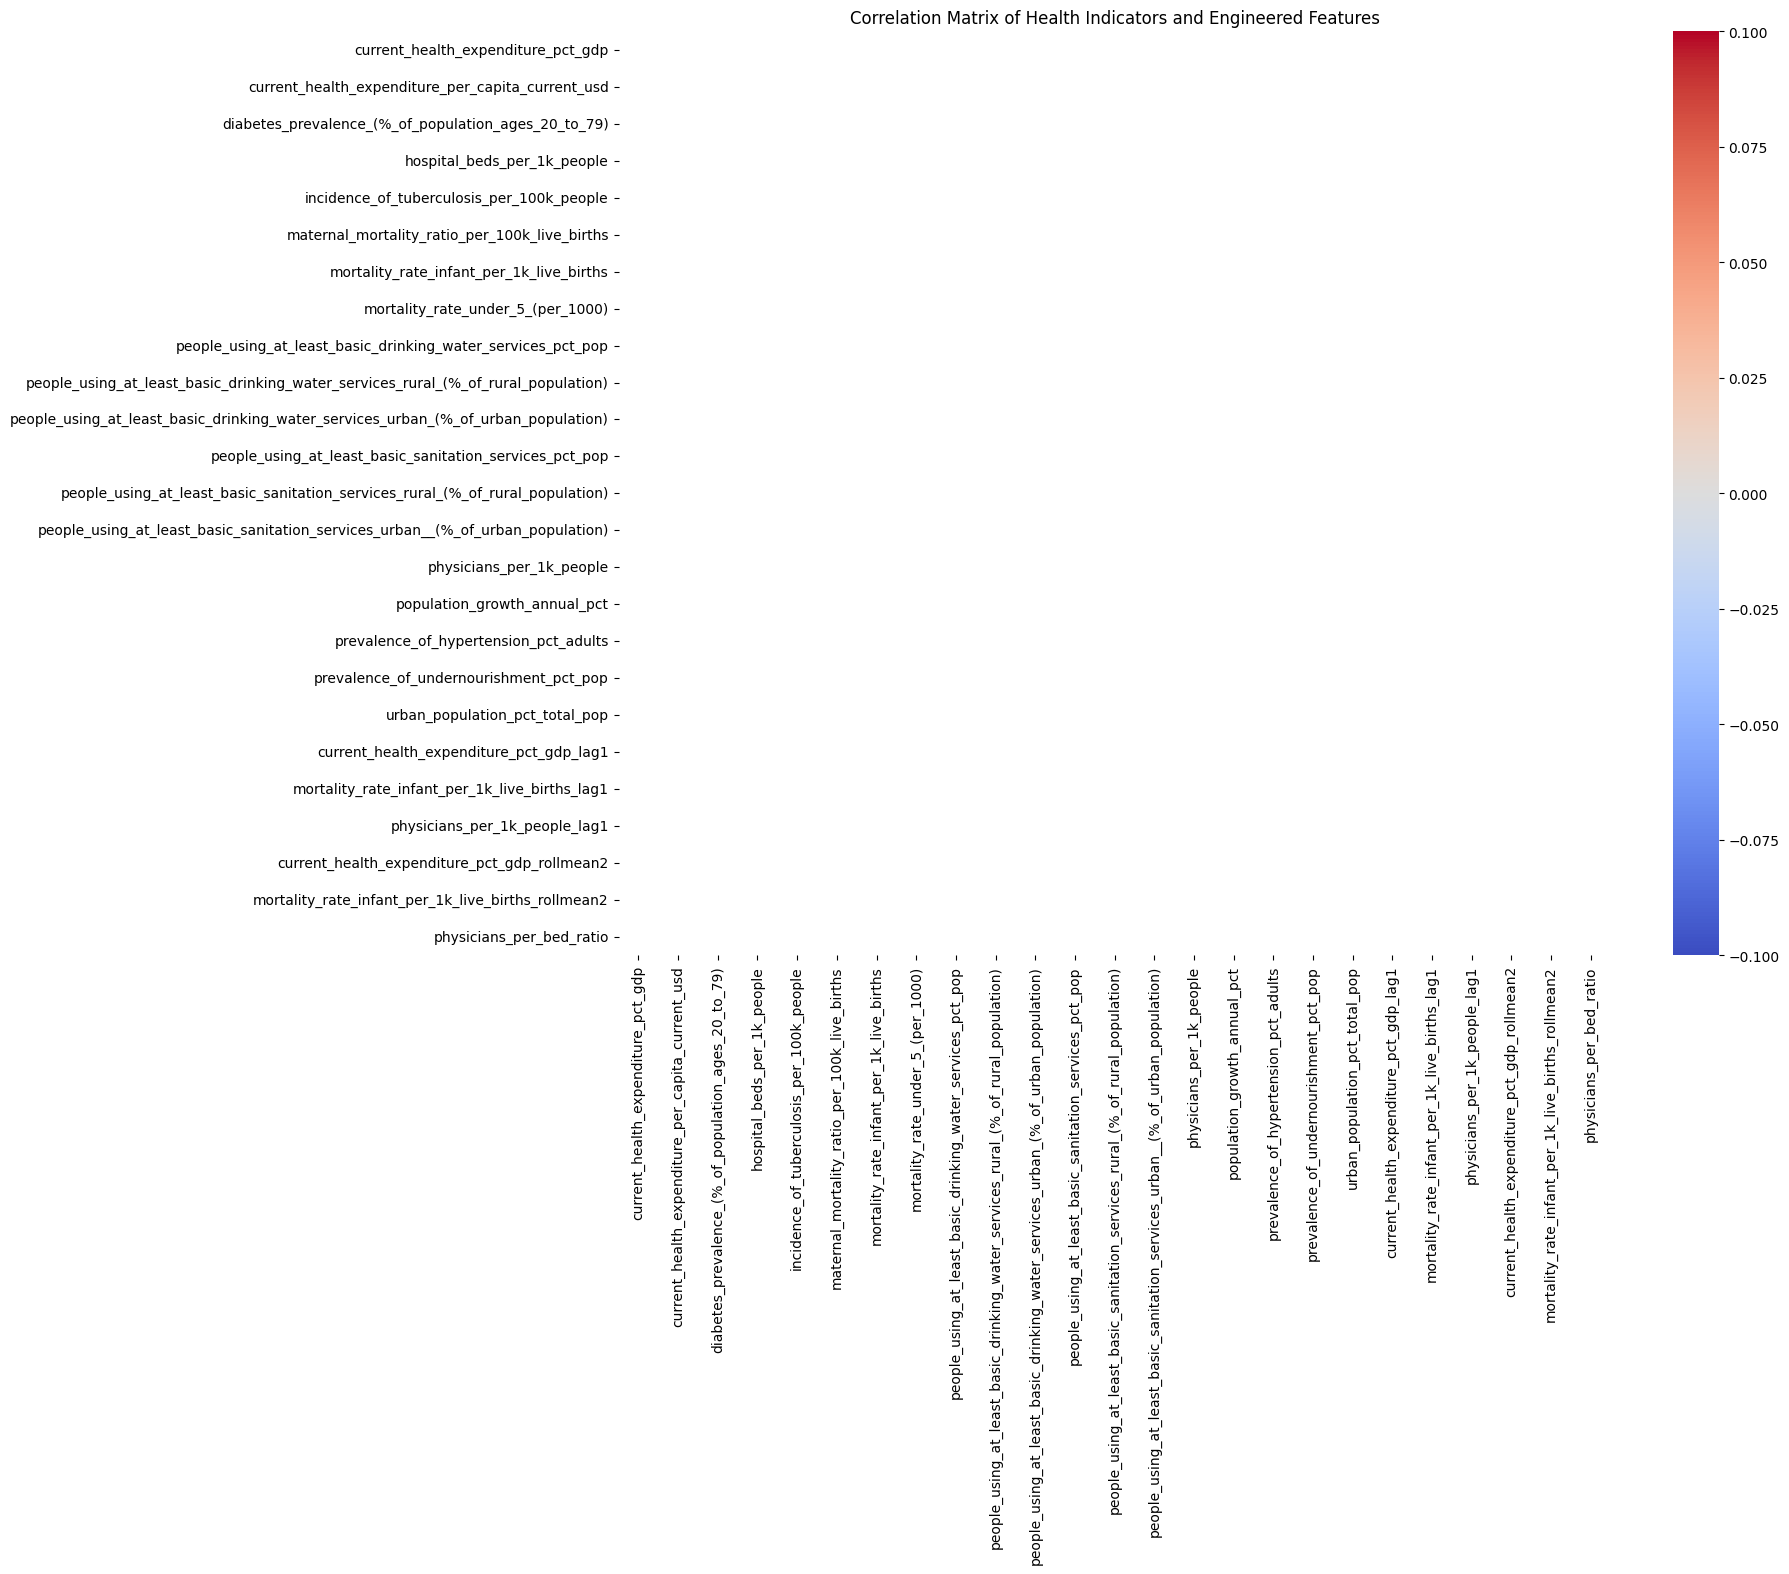

In [ ]:
# Drop non-numeric columns and 'year' before calculating correlation, keep only indicator columns
# Filter for numerical columns only
numeric_cols = df_pivot.select_dtypes(include=np.number).columns.tolist()
# Exclude 'year' if it's there as a pure numerical column not representing a continuous variable for correlation
if 'year' in numeric_cols:
    numeric_cols.remove('year')

df_corr = df_pivot[numeric_cols].dropna()

plt.figure(figsize=(16, 12))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Health Indicators and Engineered Features')
plt.show()

### 2. Country Comparison Visualizations

Comparing key indicators across our focus countries can reveal disparities and highlight areas for further investigation. We'll create visualizations to compare average values of indicators across countries.

In [ ]:
# Countries of focus as requested by the user
focus_countries = ['Pakistan', 'India', 'Indonesia', 'Iran, Islamic Rep.', 'Kazakhstan', 'Kuwait', 'Afghanistan']

# Filter the pivoted DataFrame for focus countries
df_focus_countries = df_pivot[df_pivot['country_name'].isin(focus_countries)].copy()

# Calculate average values for key indicators across years for these countries
avg_indicators = df_focus_countries.groupby('country_name')[lag_columns].mean().reset_index()

# Plotting average current health expenditure (% of GDP)
fig = px.bar(avg_indicators, x='country_name', y='current_health_expenditure_pct_gdp',
             title='Average Current Health Expenditure (% of GDP) by Country (2015-2024)',
             labels={'current_health_expenditure_pct_gdp': 'Avg. Health Expenditure (% of GDP)', 'country_name': 'Country'})
fig.show()

# Plotting average infant mortality rate
fig = px.bar(avg_indicators, x='country_name', y='mortality_rate_infant_per_1k_live_births',
             title='Average Infant Mortality Rate (per 1,000 live births) by Country (2015-2024)',
             labels={'mortality_rate_infant_per_1k_live_births': 'Avg. Infant Mortality Rate', 'country_name': 'Country'})
fig.show()

# Plotting average physicians per 1,000 people
fig = px.bar(avg_indicators, x='country_name', y='physicians_per_1k_people',
             title='Average Physicians (per 1,000 people) by Country (2015-2024)',
             labels={'physicians_per_1k_people': 'Avg. Physicians per 1k people', 'country_name': 'Country'})
fig.show()

### 3. Distribution Plots and Trend Analysis

Understanding the distribution of key indicators provides insights into their spread and central tendencies. We'll use histograms or box plots for this. Additionally, we can explore trends over time for specific indicators in more detail using line plots.

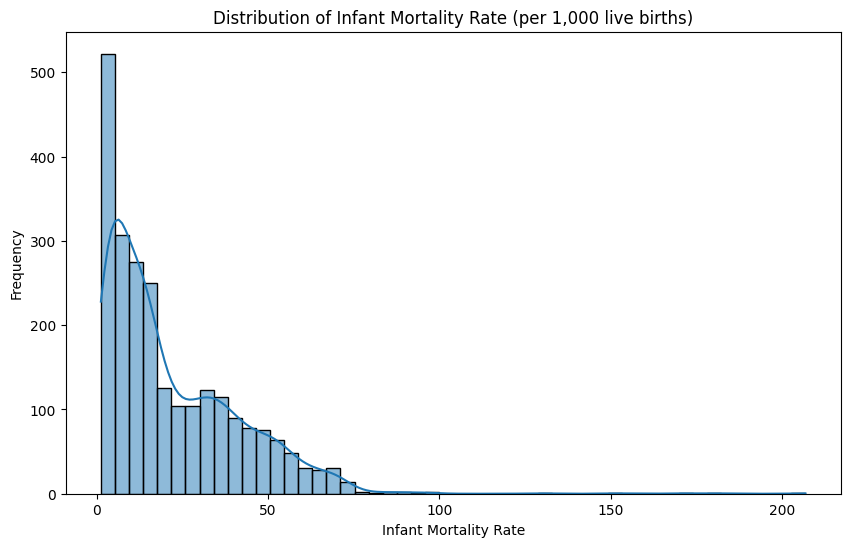

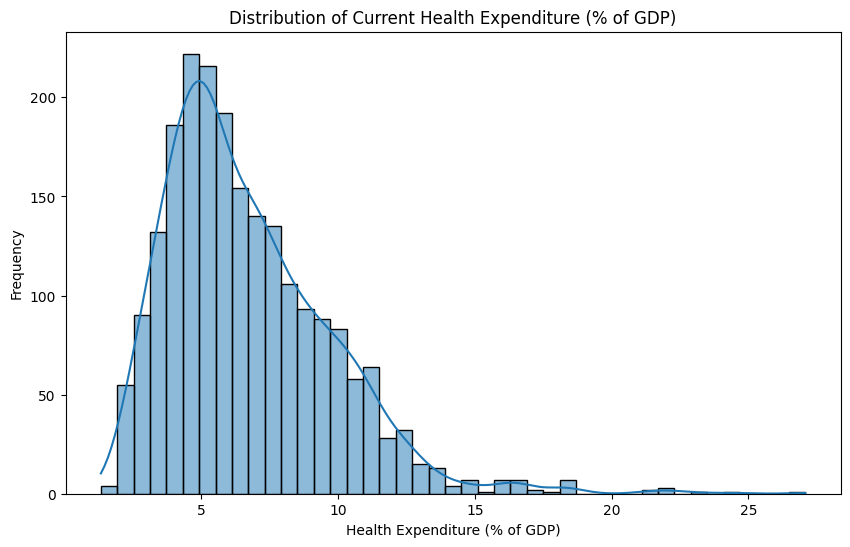

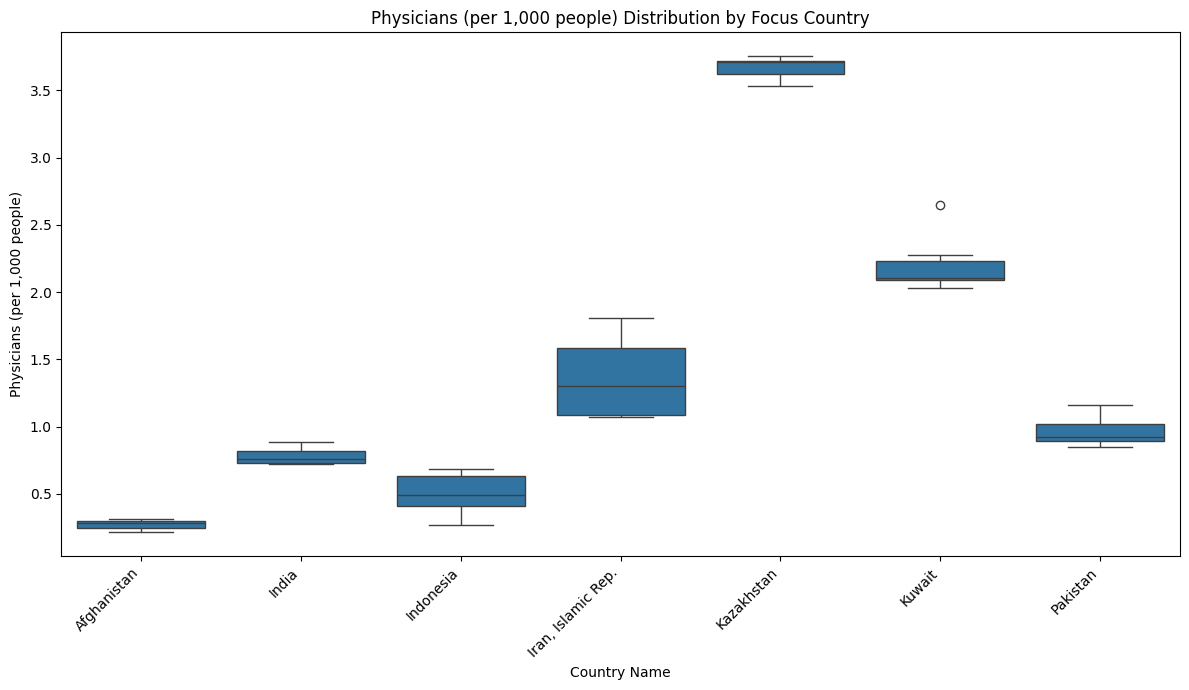

In [ ]:
# Example: Distribution of Infant Mortality Rate
plt.figure(figsize=(10, 6))
sns.histplot(df_pivot['mortality_rate_infant_per_1k_live_births'].dropna(), kde=True)
plt.title('Distribution of Infant Mortality Rate (per 1,000 live births)')
plt.xlabel('Infant Mortality Rate')
plt.ylabel('Frequency')
plt.show()

# Example: Distribution of Current health expenditure (% of GDP)
plt.figure(figsize=(10, 6))
sns.histplot(df_pivot['current_health_expenditure_pct_gdp'].dropna(), kde=True)
plt.title('Distribution of Current Health Expenditure (% of GDP)')
plt.xlabel('Health Expenditure (% of GDP)')
plt.ylabel('Frequency')
plt.show()

# Box plot for Physicians per 1,000 people across focus countries
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_focus_countries, x='country_name', y='physicians_per_1k_people')
plt.title('Physicians (per 1,000 people) Distribution by Focus Country')
plt.xlabel('Country Name')
plt.ylabel('Physicians (per 1,000 people)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Dashboard-style Visualization Section

To provide a more comprehensive overview, let's create a few more interactive plots that can be part of a dashboard. This will include scatter plots to visualize relationships between two variables, and a combined trend analysis for a broader set of countries or indicators.

In [ ]:
# Scatter plot: Infant Mortality vs. Physicians per 1,000 people
fig = px.scatter(df_pivot.dropna(subset=['mortality_rate_infant_per_1k_live_births', 'physicians_per_1k_people']),
                 x='physicians_per_1k_people', y='mortality_rate_infant_per_1k_live_births',
                 color='country_name', animation_frame='year',
                 title='Infant Mortality vs. Physicians per 1,000 People Over Time',
                 labels={'mortality_rate_infant_per_1k_live_births': 'Infant Mortality Rate', 'physicians_per_1k_people': 'Physicians per 1,000 People'},
                 hover_name='country_name', size_max=60)
fig.update_layout(xaxis_title='Physicians per 1,000 People', yaxis_title='Infant Mortality Rate')
fig.show()

# Combined Time Series Plot for Multiple Indicators for a specific country (e.g., Pakistan)
pakistan_data = df_long_cleaned_series[df_long_cleaned_series['Country Name'] == 'Pakistan'].copy()

selected_indicators_for_pakistan = [
    'Current health expenditure (% of GDP)',
    'Mortality rate, infant (per 1,000 live births)',
    'Physicians (per 1,000 people)',
    'Urban population (% of total population)'
]

df_pakistan_plot = pakistan_data[pakistan_data['Series Name'].isin(selected_indicators_for_pakistan)]

fig = px.line(
    df_pakistan_plot,
    x='Year',
    y='Value',
    color='Series Name',
    title='Key Health and Demographic Indicators in Pakistan (2015-2024)',
    labels={'Value': 'Value', 'Year': 'Year', 'Series Name': 'Indicator'},
    hover_name='Series Name',
    height=600
)
fig.update_layout(hovermode='x unified')
fig.show()

## Machine Learning Models

With the data cleaned, transformed, and explored, we can now move on to building machine learning models for the prediction tasks outlined. We will tackle each task separately, focusing on model building, training, and evaluation.

### Task A: Predict Infant Mortality Rate (Regression)

**Goal:** Predict 'Mortality rate, infant (per 1,000 live births)' using various health and demographic indicators.

**Features:** 'Current health expenditure (% of GDP)', 'Physicians (per 1,000 people)', 'Hospital beds (per 1,000 people)', 'People using at least basic drinking water services (% of population)', 'Diabetes prevalence (% of population ages 20 to 79)', 'Incidence of tuberculosis (per 100,000 people)'.

**Models:** Linear Regression, Random Forest, XGBoost, Keras (simple neural network).

**Evaluation:** RMSE, MAE, R², cross-validation.

#### 1. Data Preparation for Task A

First, we need to select the relevant features and the target variable, drop rows with missing values that are critical for this task, and then split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define target and features for Task A
target_A = 'mortality_rate_infant_per_1k_live_births'
features_A = [
    'current_health_expenditure_pct_gdp',
    'physicians_per_1k_people',
    'hospital_beds_per_1k_people',
    'people_using_at_least_basic_drinking_water_services_pct_pop',
    'diabetes_prevalence_(%_of_population_ages_20_to_79)',
    'incidence_of_tuberculosis_per_100k_people'
]

# Create a copy to avoid SettingWithCopyWarning
df_task_A = df_pivot.copy()

# Impute missing values for the 'diabetes_prevalence' column with its mean
# This column has significantly fewer non-null values and causes the DataFrame to become empty with dropna
df_task_A['diabetes_prevalence_(%_of_population_ages_20_to_79)'].fillna(
    df_task_A['diabetes_prevalence_(%_of_population_ages_20_to_79)'].mean(),
    inplace=True
)

# Now filter out rows where the target or any other feature for Task A is NaN
df_task_A = df_task_A.dropna(subset=[target_A] + [f for f in features_A if f != 'diabetes_prevalence_(%_of_population_ages_20_to_79)']).copy()

X = df_task_A[features_A]
y = df_task_A[target_A]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (675, 6)
Shape of X_test: (169, 6)
Shape of y_train: (675,)
Shape of y_test: (169,)


/tmp/ipykernel_1873/3162325214.py:20: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





#### 2. Model Implementation and Evaluation for Task A

We will now implement and evaluate Linear Regression, Random Forest, XGBoost, and a simple Keras neural network for predicting infant mortality rate.

##### a. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

# Initialize and train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lin_reg = lin_reg.predict(X_test_scaled)

# Evaluate the model
rmse_lin_reg = np.sqrt(mean_squared_error(y_test, y_pred_lin_reg))
mae_lin_reg = mean_absolute_error(y_test, y_pred_lin_reg)
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)

print(f"Linear Regression RMSE: {rmse_lin_reg:.2f}")
print(f"Linear Regression MAE: {mae_lin_reg:.2f}")
print(f"Linear Regression R²: {r2_lin_reg:.2f}")

# Perform cross-validation
cv_scores_lin_reg = cross_val_score(lin_reg, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"Linear Regression Cross-Validation RMSE (mean): {-cv_scores_lin_reg.mean():.2f} (+/- {cv_scores_lin_reg.std():.2f})")

Linear Regression RMSE: 8.48
Linear Regression MAE: 5.81
Linear Regression R²: 0.73
Linear Regression Cross-Validation RMSE (mean): 7.20 (+/- 0.64)


##### b. Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf_reg = rf_reg.predict(X_test_scaled)

# Evaluate the model
rmse_rf_reg = np.sqrt(mean_squared_error(y_test, y_pred_rf_reg))
mae_rf_reg = mean_absolute_error(y_test, y_pred_rf_reg)
r2_rf_reg = r2_score(y_test, y_pred_rf_reg)

print(f"Random Forest RMSE: {rmse_rf_reg:.2f}")
print(f"Random Forest MAE: {mae_rf_reg:.2f}")
print(f"Random Forest R²: {r2_rf_reg:.2f}")

# Perform cross-validation
cv_scores_rf_reg = cross_val_score(rf_reg, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"Random Forest Cross-Validation RMSE (mean): {-cv_scores_rf_reg.mean():.2f} (+/- {cv_scores_rf_reg.std():.2f})")

Random Forest RMSE: 5.44
Random Forest MAE: 3.08
Random Forest R²: 0.89
Random Forest Cross-Validation RMSE (mean): 3.84 (+/- 0.36)


##### c. XGBoost Regressor

In [ ]:
import xgboost as xgb

# Initialize and train the model
xgb_reg = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_xgb_reg = xgb_reg.predict(X_test_scaled)

# Evaluate the model
rmse_xgb_reg = np.sqrt(mean_squared_error(y_test, y_pred_xgb_reg))
mae_xgb_reg = mean_absolute_error(y_test, y_pred_xgb_reg)
r2_xgb_reg = r2_score(y_test, y_pred_xgb_reg)

print(f"XGBoost RMSE: {rmse_xgb_reg:.2f}")
print(f"XGBoost MAE: {mae_xgb_reg:.2f}")
print(f"XGBoost R²: {r2_xgb_reg:.2f}")

# Perform cross-validation
cv_scores_xgb_reg = cross_val_score(xgb_reg, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"XGBoost Cross-Validation RMSE (mean): {-cv_scores_xgb_reg.mean():.2f} (+/- {cv_scores_xgb_reg.std():.2f})")

XGBoost RMSE: 5.91
XGBoost MAE: 3.08
XGBoost R²: 0.87
XGBoost Cross-Validation RMSE (mean): 3.89 (+/- 0.41)


##### d. Simple Neural Network (Keras)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Neural Network RMSE: 8.14
Neural Network MAE: 5.32
Neural Network R²: 0.75


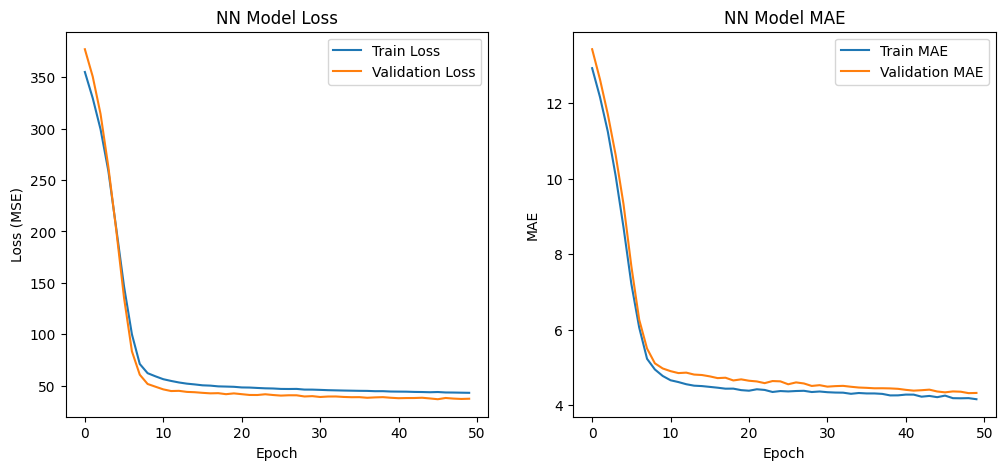

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build the neural network model
def build_nn_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # Output layer for regression
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

nn_model = build_nn_model()

# Train the model
history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # Set to 1 for progress bars
)

# Make predictions
y_pred_nn = nn_model.predict(X_test_scaled).flatten()

# Evaluate the model
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Neural Network RMSE: {rmse_nn:.2f}")
print(f"Neural Network MAE: {mae_nn:.2f}")
print(f"Neural Network R²: {r2_nn:.2f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('NN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('NN Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

#### Summary of Task A (Infant Mortality Rate Prediction) Models

Here's a comparison of the evaluation metrics for the regression models:

In [ ]:
results_A = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Neural Network'],
    'RMSE': [rmse_lin_reg, rmse_rf_reg, rmse_xgb_reg, rmse_nn],
    'MAE': [mae_lin_reg, mae_rf_reg, mae_xgb_reg, mae_nn],
    'R2 Score': [r2_lin_reg, r2_rf_reg, r2_xgb_reg, r2_nn]
})
display(results_A.sort_values(by='RMSE'))

,Model,RMSE,MAE,R2 Score
1,Random Forest,5.437918,3.075439,0.889315
2,XGBoost,5.913150,3.082976,0.869123
3,Neural Network,8.141332,5.322914,0.751906
0,Linear Regression,8.475403,5.814969,0.731128


### Task B: Classify High vs Low Health Expenditure (Classification)

**Goal:** Perform binary classification to predict whether a country's health expenditure is above or below the median.

**Target:** A new binary variable 'High_Health_Expenditure' (1 if above median, 0 if below or equal to median).

**Features:** 'Population growth (annual %)', 'Urban population (% of total population)', 'Mortality rate, infant (per 1,000 live births)', 'Incidence of tuberculosis (per 100,000 people)', 'Diabetes prevalence (% of population ages 20 to 79)'.

**Models:** Logistic Regression, Random Forest Classifier, Support Vector Machine (SVM).

**Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC.

#### 1. Data Preparation for Task B

We will create the binary target variable, select relevant features, handle missing values, and split the data for training and testing.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Define target feature (Current health expenditure (% of GDP)) and features for Task B
classification_target = 'current_health_expenditure_pct_gdp'
features_B = [
    'population_growth_annual_pct',
    'urban_population_pct_total_pop',
    'mortality_rate_infant_per_1k_live_births',
    'incidence_of_tuberculosis_per_100k_people',
    'diabetes_prevalence_(%_of_population_ages_20_to_79)' # Corrected column name
]

# Filter out rows where the classification target or any feature for Task B is NaN
df_task_B = df_pivot.dropna(subset=[classification_target] + features_B).copy()

# Create the binary target variable: 1 for above median, 0 for below or equal to median
median_expenditure = df_task_B[classification_target].median()
df_task_B['High_Health_Expenditure'] = (df_task_B[classification_target] > median_expenditure).astype(int)

X_B = df_task_B[features_B]
y_B = df_task_B['High_Health_Expenditure']

# Split the data into training and testing sets
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_B, test_size=0.2, random_state=42, stratify=y_B)

# Standardize features
scaler_B = StandardScaler()
X_train_scaled_B = scaler_B.fit_transform(X_train_B)
X_test_scaled_B = scaler_B.transform(X_test_B)

print(f"Shape of X_train_B: {X_train_B.shape}")
print(f"Shape of X_test_B: {X_test_B.shape}")
print(f"Shape of y_train_B: {y_train_B.shape}")
print(f"Shape of y_test_B: {y_test_B.shape}")
print(f"Target variable distribution in training set:\n{y_train_B.value_counts(normalize=True)}")

Shape of X_train_B: (17, 5)
Shape of X_test_B: (5, 5)
Shape of y_train_B: (17,)
Shape of y_test_B: (5,)
Target variable distribution in training set:
High_Health_Expenditure
1    0.529412
0    0.470588
Name: proportion, dtype: float64


#### 2. Model Implementation and Evaluation for Task B

We will now implement and evaluate Logistic Regression, Random Forest Classifier, and SVM for classifying health expenditure.

##### a. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train_scaled_B, y_train_B)

# Make predictions
y_pred_log_reg = log_reg.predict(X_test_scaled_B)
y_prob_log_reg = log_reg.predict_proba(X_test_scaled_B)[:, 1]

# Evaluate the model
acc_log_reg = accuracy_score(y_test_B, y_pred_log_reg)
prec_log_reg = precision_score(y_test_B, y_pred_log_reg)
rec_log_reg = recall_score(y_test_B, y_pred_log_reg)
f1_log_reg = f1_score(y_test_B, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test_B, y_prob_log_reg)

print(f"Logistic Regression Accuracy: {acc_log_reg:.2f}")
print(f"Logistic Regression Precision: {prec_log_reg:.2f}")
print(f"Logistic Regression Recall: {rec_log_reg:.2f}")
print(f"Logistic Regression F1-Score: {f1_log_reg:.2f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_log_reg:.2f}")

Logistic Regression Accuracy: 0.60
Logistic Regression Precision: 0.50
Logistic Regression Recall: 0.50
Logistic Regression F1-Score: 0.50
Logistic Regression ROC-AUC: 0.67


##### b. Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled_B, y_train_B)

# Make predictions
y_pred_rf_clf = rf_clf.predict(X_test_scaled_B)
y_prob_rf_clf = rf_clf.predict_proba(X_test_scaled_B)[:, 1]

# Evaluate the model
acc_rf_clf = accuracy_score(y_test_B, y_pred_rf_clf)
prec_rf_clf = precision_score(y_test_B, y_pred_rf_clf)
rec_rf_clf = recall_score(y_test_B, y_pred_rf_clf)
f1_rf_clf = f1_score(y_test_B, y_pred_rf_clf)
roc_auc_rf_clf = roc_auc_score(y_test_B, y_prob_rf_clf)

print(f"Random Forest Classifier Accuracy: {acc_rf_clf:.2f}")
print(f"Random Forest Classifier Precision: {prec_rf_clf:.2f}")
print(f"Random Forest Classifier Recall: {rec_rf_clf:.2f}")
print(f"Random Forest Classifier F1-Score: {f1_rf_clf:.2f}")
print(f"Random Forest Classifier ROC-AUC: {roc_auc_rf_clf:.2f}")

Random Forest Classifier Accuracy: 0.60
Random Forest Classifier Precision: 0.50
Random Forest Classifier Recall: 0.50
Random Forest Classifier F1-Score: 0.50
Random Forest Classifier ROC-AUC: 0.50


##### c. Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

# Initialize and train the model
# Use probability=True for ROC-AUC, but it makes training slower
svm_clf = SVC(random_state=42, probability=True)
svm_clf.fit(X_train_scaled_B, y_train_B)

# Make predictions
y_pred_svm_clf = svm_clf.predict(X_test_scaled_B)
y_prob_svm_clf = svm_clf.predict_proba(X_test_scaled_B)[:, 1]

# Evaluate the model
acc_svm_clf = accuracy_score(y_test_B, y_pred_svm_clf)
prec_svm_clf = precision_score(y_test_B, y_pred_svm_clf)
rec_svm_clf = recall_score(y_test_B, y_pred_svm_clf)
f1_svm_clf = f1_score(y_test_B, y_pred_svm_clf)
roc_auc_svm_clf = roc_auc_score(y_test_B, y_prob_svm_clf)

print(f"SVM Classifier Accuracy: {acc_svm_clf:.2f}")
print(f"SVM Classifier Precision: {prec_svm_clf:.2f}")
print(f"SVM Classifier Recall: {rec_svm_clf:.2f}")
print(f"SVM Classifier F1-Score: {f1_svm_clf:.2f}")
print(f"SVM Classifier ROC-AUC: {roc_auc_svm_clf:.2f}")

SVM Classifier Accuracy: 0.40
SVM Classifier Precision: 0.33
SVM Classifier Recall: 0.50
SVM Classifier F1-Score: 0.40
SVM Classifier ROC-AUC: 0.33


#### Summary of Task B (High vs Low Health Expenditure Classification) Models

Here's a comparison of the evaluation metrics for the classification models:

In [ ]:
results_B = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Classifier', 'SVM Classifier'],
    'Accuracy': [acc_log_reg, acc_rf_clf, acc_svm_clf],
    'Precision': [prec_log_reg, prec_rf_clf, prec_svm_clf],
    'Recall': [rec_log_reg, rec_rf_clf, rec_svm_clf],
    'F1-Score': [f1_log_reg, f1_rf_clf, f1_svm_clf],
    'ROC-AUC': [roc_auc_log_reg, roc_auc_rf_clf, roc_auc_svm_clf]
})
display(results_B.sort_values(by='Accuracy', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6,0.500000,0.5,0.5,0.666667
1,Random Forest Classifier,0.6,0.500000,0.5,0.5,0.500000
2,SVM Classifier,0.4,0.333333,0.5,0.4,0.333333


#### ROC Curves for Classification Models

Visualizing the Receiver Operating Characteristic (ROC) curve helps understand the trade-off between the true positive rate and false positive rate at various threshold settings.

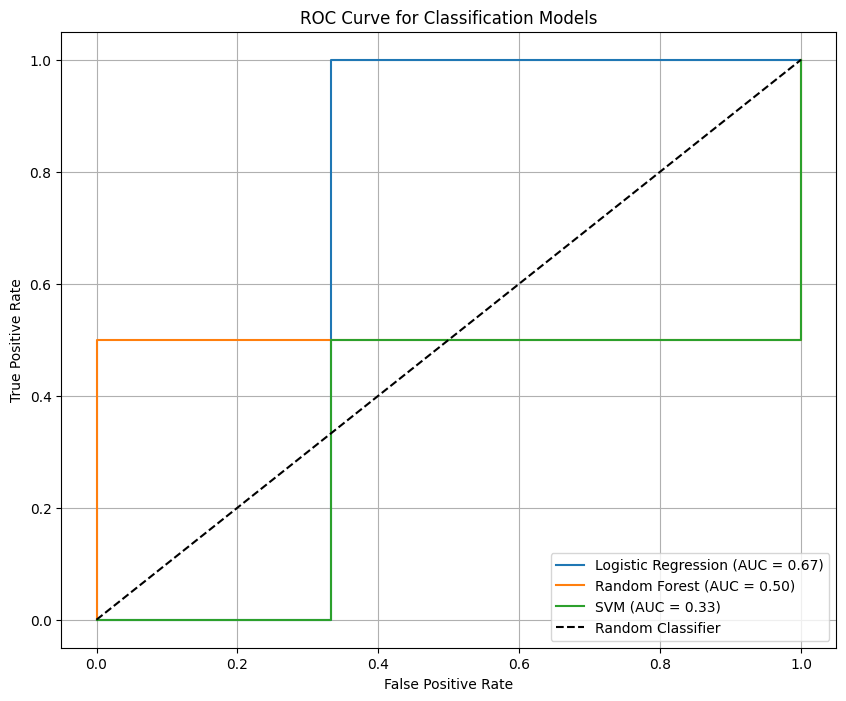

In [ ]:
plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test_B, y_prob_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')

# Random Forest Classifier
fpr_rf_clf, tpr_rf_clf, _ = roc_curve(y_test_B, y_prob_rf_clf)
plt.plot(fpr_rf_clf, tpr_rf_clf, label=f'Random Forest (AUC = {roc_auc_rf_clf:.2f})')

# SVM Classifier
fpr_svm_clf, tpr_svm_clf, _ = roc_curve(y_test_B, y_prob_svm_clf)
plt.plot(fpr_svm_clf, tpr_svm_clf, label=f'SVM (AUC = {roc_auc_svm_clf:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classification Models')
plt.legend()
plt.grid(True)
plt.show()

### Task C: Time Series Forecasting (for Pakistan)

**Goal:** Forecast 'Current health expenditure (% of GDP)' for Pakistan for the next 3 years.

**Models:** ARIMA, Prophet, LSTM.

**Evaluation:** Show predictions with confidence intervals.

#### 1. Data Preparation for Task C

We need to filter the data specifically for Pakistan and the 'Current health expenditure (% of GDP)' indicator. For time series models, the data needs to be indexed by time.

In [ ]:
# Filter data for Pakistan and the target indicator
pakistan_health_exp = df_pivot[
    (df_pivot['country_name'] == 'Pakistan')
].copy()

# Select the relevant columns and set 'Year' as index
pakistan_health_exp = pakistan_health_exp[['year', 'current_health_expenditure_pct_gdp']].set_index('year')
pakistan_health_exp = pakistan_health_exp.rename(columns={'current_health_expenditure_pct_gdp': 'value'})

# Drop NaN values for the target variable (if any remaining in this subset)
pakistan_health_exp.dropna(inplace=True)

print("Pakistan Health Expenditure Data (first 5 rows):")
display(pakistan_health_exp.head())
print("\nPakistan Health Expenditure Data (last 5 rows):")
display(pakistan_health_exp.tail())
pakistan_health_exp.info()

Pakistan Health Expenditure Data (first 5 rows):


,value
year,
2015,2.494933
2016,2.570264
2017,2.786301
2018,2.828449
2019,2.847369



Pakistan Health Expenditure Data (last 5 rows):


,value
year,
2019,2.847369
2020,2.952730
2021,2.990158
2022,2.903548
2023,2.519883


<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 2015 to 2023
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   9 non-null      float64
dtypes: float64(1)
memory usage: 144.0 bytes


#### 2. Model Implementation and Forecasting for Task C

We will now apply ARIMA, Prophet, and LSTM models to forecast Pakistan's health expenditure.

##### a. ARIMA Model

ARIMA (AutoRegressive Integrated Moving Average) is a statistical model that uses time series data to better understand the data or to predict future points in the series.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.



                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                    9
Model:                 ARIMA(1, 1, 1)   Log Likelihood                   4.240
Date:                Sun, 07 Jun 2026   AIC                             -2.480
Time:                        04:19:13   BIC                             -2.242
Sample:                             0   HQIC                            -4.088
                                  - 9                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2229      1.371      0.163      0.871      -2.465       2.911
ma.L1          0.9848     34.803      0.028      0.977     -67.228      69.197
sigma2         0.0149      0.505      0.029      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/tmp/ipykernel_1873/53781206.py:17: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



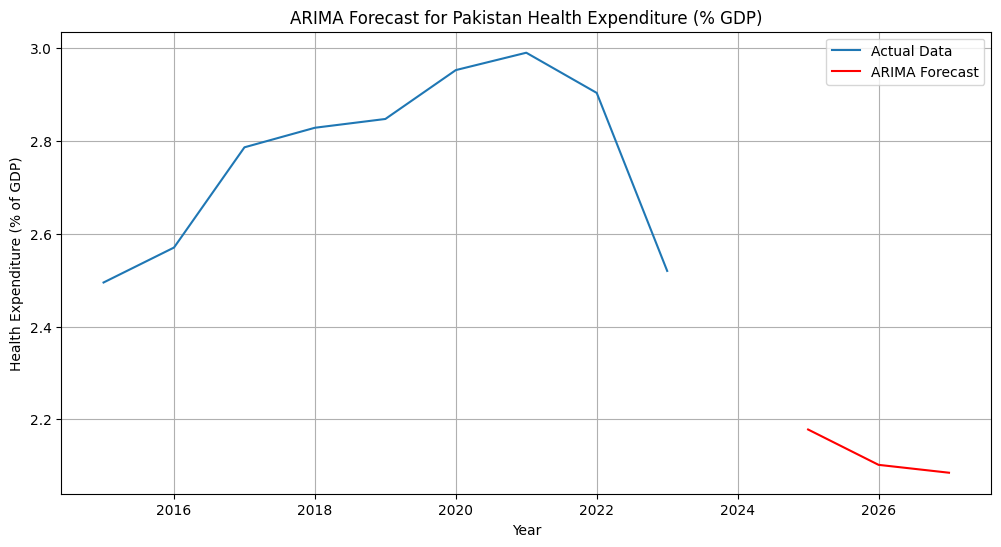

ARIMA Forecast for 2025-2027:


,ARIMA_Forecast
2025,2.178113
2026,2.101934
2027,2.084954


In [ ]:
import statsmodels.api as sm

# Determine p, d, q for ARIMA. This usually involves ACF/PACF plots or auto_arima.
# For simplicity, we'll start with a common (1,1,1) order and let the user refine if needed.
# Given the limited number of data points (2015-2024, 10 years), simpler models are better.
# d=1 for differencing, as time series often exhibit trend.

# Fit ARIMA model
# Seasonal=False as we only have yearly data, not enough to detect seasonality easily
model_arima = sm.tsa.ARIMA(pakistan_health_exp['value'], order=(1,1,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

# Forecast for the next 3 years (2025-2027)
forecast_arima = model_arima_fit.forecast(steps=3)
forecast_index_arima = pd.date_range(start='2025', periods=3, freq='Y').year
forecast_arima_series = pd.Series(forecast_arima.values, index=forecast_index_arima, name='ARIMA_Forecast')

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(pakistan_health_exp['value'], label='Actual Data')
plt.plot(forecast_arima_series, label='ARIMA Forecast', color='red')
plt.title('ARIMA Forecast for Pakistan Health Expenditure (% GDP)')
plt.xlabel('Year')
plt.ylabel('Health Expenditure (% of GDP)')
plt.legend()
plt.grid(True)
plt.show()

print("ARIMA Forecast for 2025-2027:")
display(forecast_arima_series)

##### b. Prophet Model

Prophet is a forecasting tool developed by Facebook, designed for forecasting univariate time series with additive models. It's particularly good for datasets with strong seasonal effects and holidays.

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



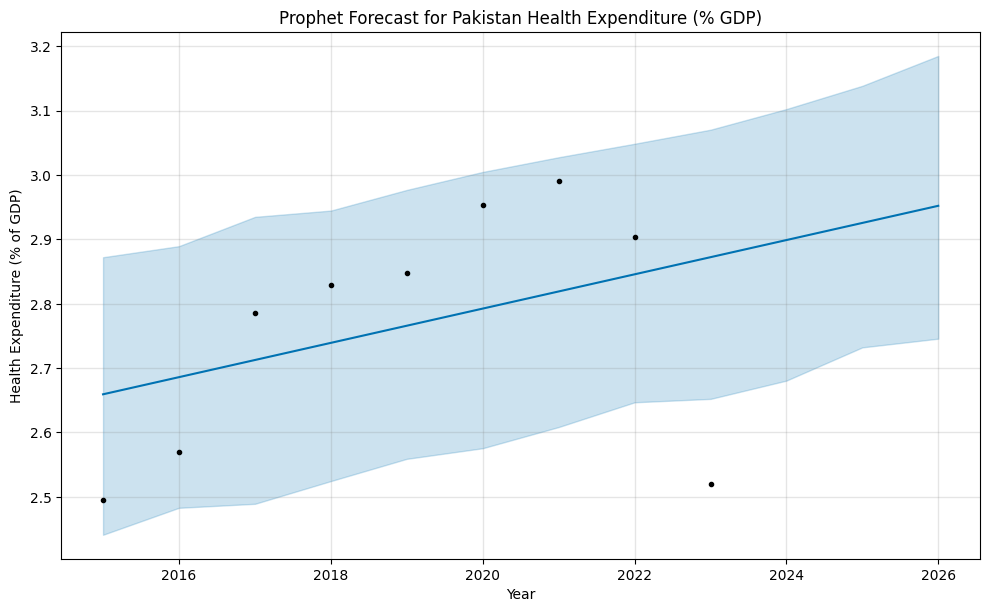

Prophet Forecast for 2025-2027 (including confidence intervals): 


,ds,yhat,yhat_lower,yhat_upper
10,2024-12-31,2.925495,2.732112,3.138562
11,2025-12-31,2.952104,2.745620,3.184971


In [ ]:
from prophet import Prophet

# Prophet requires columns 'ds' (datestamp) and 'y' (value)
df_prophet = pakistan_health_exp.reset_index().rename(columns={'year': 'ds', 'value': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], format='%Y')

# Initialize and fit the Prophet model
model_prophet = Prophet(yearly_seasonality=False) # Not enough data points to reliably detect yearly seasonality
model_prophet.fit(df_prophet)

# Create a future DataFrame for predictions (next 3 years)
future_prophet = model_prophet.make_future_dataframe(periods=3, freq='Y')

# Make predictions
forecast_prophet = model_prophet.predict(future_prophet)

# Filter forecast to only show the future predictions
forecast_prophet_future = forecast_prophet[forecast_prophet['ds'].dt.year > pakistan_health_exp.index.max()]

# Plotting
fig = model_prophet.plot(forecast_prophet)
plt.title('Prophet Forecast for Pakistan Health Expenditure (% GDP)')
plt.xlabel('Year')
plt.ylabel('Health Expenditure (% of GDP)')
plt.show()

# Plotting components (trend, seasonality) - may not be meaningful with yearly_seasonality=False
# fig2 = model_prophet.plot_components(forecast_prophet)
# plt.show()

print("Prophet Forecast for 2025-2027 (including confidence intervals): ")
display(forecast_prophet_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

##### c. LSTM Model (Optional but requested)

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network (RNN) well-suited for sequence prediction problems. They require data to be structured as sequences (timesteps).

Given the very limited number of time points (10 years), a complex LSTM model might not generalize well and could easily overfit. However, for demonstration as requested, we can build a very simple one. Data scaling is crucial for LSTMs.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

/tmp/ipykernel_1873/2464441035.py:58: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



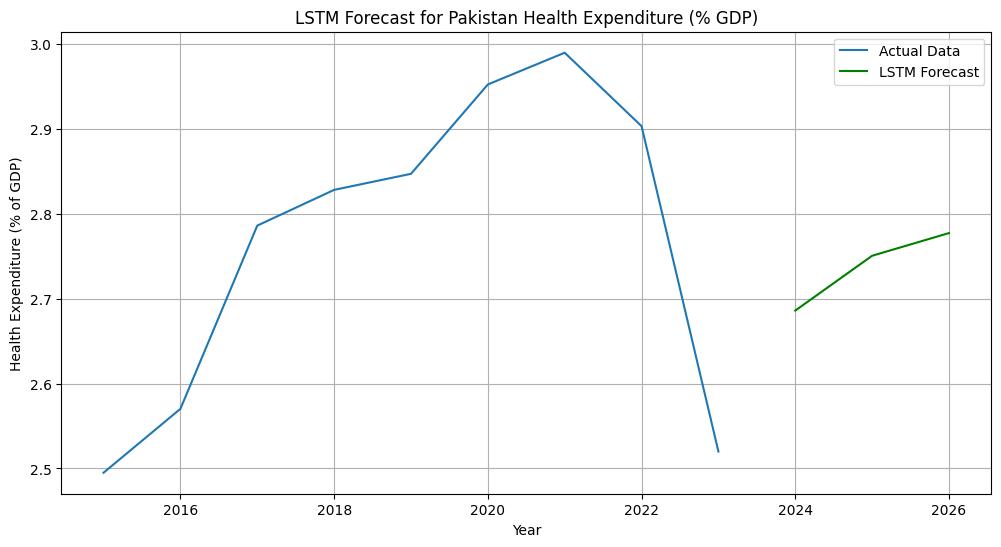

LSTM Forecast for 2025-2027:


,LSTM_Forecast
2024,2.686141
2025,2.750765
2026,2.777526


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Prepare data for LSTM
data = pakistan_health_exp['value'].values.reshape(-1, 1)

# Scale the data
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler_lstm.fit_transform(data)

# Create sequences for LSTM (e.g., predict next value based on previous 3 values)
def create_sequences(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 1 # Using previous year to predict next
X_lstm, y_lstm = create_sequences(data_scaled, look_back)

# Reshape input to be [samples, time steps, features]
X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], 1))

# Split into train and test sets (though for forecasting, we use all available data for training)
# Here, we'll just train on the full available sequence to maximize data for the model

# Build the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# Train the model
# Use epochs carefully with small datasets to avoid overfitting. verbose=0 to hide output
model_lstm.fit(X_lstm, y_lstm, epochs=100, batch_size=1, verbose=0)

# Prepare input for forecasting (last 'look_back' values from the original data)
last_sequence = data_scaled[-look_back:].reshape(1, look_back, 1)

# Forecast the next 3 years
forecast_lstm_values = []
current_input = last_sequence

for _ in range(3):
    predicted_value_scaled = model_lstm.predict(current_input, verbose=0)[0, 0]
    forecast_lstm_values.append(predicted_value_scaled)
    # Update current_input for the next prediction by removing the oldest and adding the new prediction
    # The predicted_value_scaled needs to be reshaped to (1, 1, 1) to match dimensions for concatenation
    predicted_value_reshaped = np.array(predicted_value_scaled).reshape(1, 1, 1)
    current_input = np.concatenate((current_input[:, 1:, :], predicted_value_reshaped), axis=1)

# Inverse transform the forecasts to original scale
forecast_lstm_values = scaler_lstm.inverse_transform(np.array(forecast_lstm_values).reshape(-1, 1)).flatten()

# Create a Series for the forecast
forecast_index_lstm = pd.date_range(start=str(pakistan_health_exp.index.max() + 1), periods=3, freq='Y').year
forecast_lstm_series = pd.Series(forecast_lstm_values, index=forecast_index_lstm, name='LSTM_Forecast')

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(pakistan_health_exp['value'], label='Actual Data')
plt.plot(forecast_lstm_series, label='LSTM Forecast', color='green')
plt.title('LSTM Forecast for Pakistan Health Expenditure (% GDP)')
plt.xlabel('Year')
plt.ylabel('Health Expenditure (% of GDP)')
plt.legend()
plt.grid(True)
plt.show()

print("LSTM Forecast for 2025-2027:")
display(forecast_lstm_series)

#### Summary of Task C (Time Series Forecasting) Models

Here's a comparison of the forecasts from ARIMA, Prophet, and LSTM for Pakistan's health expenditure.

Comparison of Forecasts (Health Expenditure % GDP for Pakistan):


,ARIMA,Prophet,LSTM
2024,2.178113,2.925495,2.686141
2025,2.101934,2.952104,2.750765
2026,2.084954,NaN,2.777526


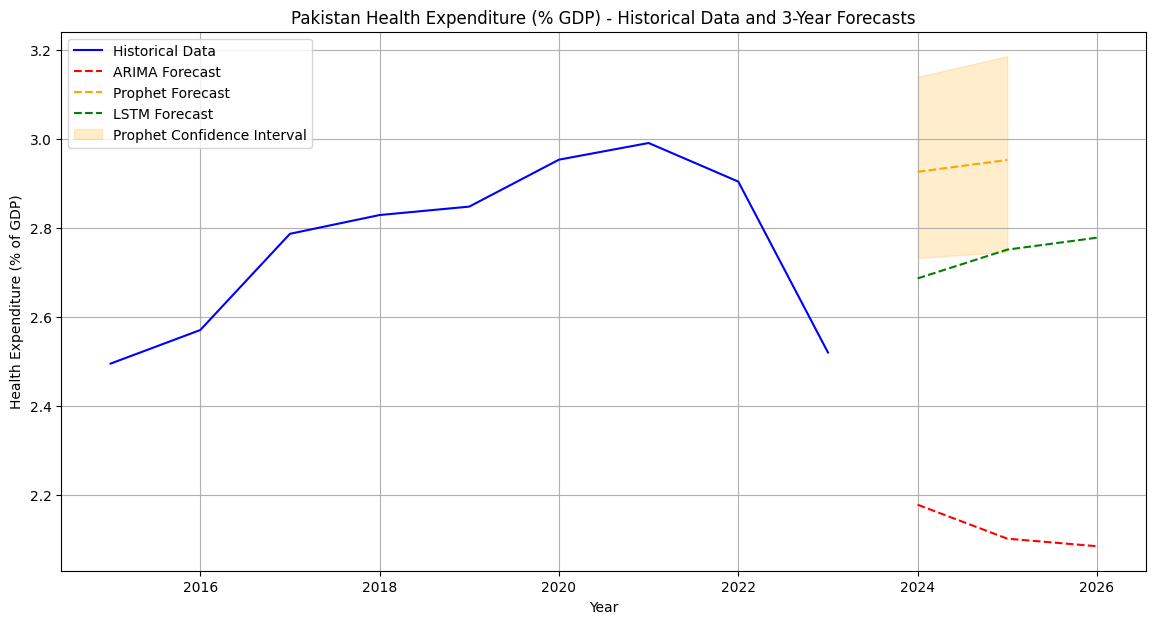

In [ ]:
print("Comparison of Forecasts (Health Expenditure % GDP for Pakistan):")

# Define a common index for the forecast comparison (2024, 2025, 2026)
# This aligns with the 'next 3 years' expectation and LSTM's output
common_forecast_index = forecast_lstm_series.index

# Correct ARIMA forecast series by re-assigning the index
# The values in forecast_arima are for 2024, 2025, 2026, but the index was incorrectly labeled.
arima_corrected = pd.Series(forecast_arima.values, index=common_forecast_index, name='ARIMA_Forecast')

# Align Prophet forecast to the common index
# Prophet forecast currently covers 2024, 2025. Reindexing will result in NaN for 2026.
prophet_series_current_years = pd.Series(forecast_prophet_future['yhat'].values,
                                         index=forecast_prophet_future['ds'].dt.year)
prophet_aligned = prophet_series_current_years.reindex(common_forecast_index)

# Align Prophet confidence intervals
prophet_lower_aligned = pd.Series(forecast_prophet_future['yhat_lower'].values,
                                  index=forecast_prophet_future['ds'].dt.year).reindex(common_forecast_index)
prophet_upper_aligned = pd.Series(forecast_prophet_future['yhat_upper'].values,
                                  index=forecast_prophet_future['ds'].dt.year).reindex(common_forecast_index)

forecast_comparison = pd.DataFrame({
    'ARIMA': arima_corrected,
    'Prophet': prophet_aligned,
    'LSTM': forecast_lstm_series
}, index=common_forecast_index)
display(forecast_comparison)

# Plot all forecasts together with historical data
plt.figure(figsize=(14, 7))
plt.plot(pakistan_health_exp['value'], label='Historical Data', color='blue')
plt.plot(forecast_comparison['ARIMA'], label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(forecast_comparison['Prophet'], label='Prophet Forecast', color='orange', linestyle='--')
plt.plot(forecast_comparison['LSTM'], label='LSTM Forecast', color='green', linestyle='--')

# Add Prophet's confidence intervals if available for visual comparison
plt.fill_between(
    common_forecast_index, # Use the common index for plotting
    prophet_lower_aligned,
    prophet_upper_aligned,
    color='orange', alpha=0.2, label='Prophet Confidence Interval'
)

plt.title('Pakistan Health Expenditure (% GDP) - Historical Data and 3-Year Forecasts')
plt.xlabel('Year')
plt.ylabel('Health Expenditure (% of GDP)')
plt.legend()
plt.grid(True)
plt.show()

## Model Optimization

Now that we have baseline models, we can look into optimizing their performance through hyperparameter tuning and analyzing feature importance.

### 1. Hyperparameter Tuning (Grid Search)

Hyperparameter tuning helps to find the optimal set of hyperparameters for a model, which can significantly improve its performance. We will use `GridSearchCV` on the Random Forest Regressor from Task A to find better parameters.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest Regressor
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                              param_grid=param_grid_rf,
                              cv=3,
                              scoring='neg_root_mean_squared_error',
                              n_jobs=-1,
                              verbose=1)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_scaled, y_train)

print(f"Best parameters found for Random Forest: {grid_search_rf.best_params_}")
print(f"Best RMSE score (negative) for Random Forest: {grid_search_rf.best_score_:.2f}")

# Evaluate the best model on the test set
best_rf_reg = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_reg.predict(X_test_scaled)

rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"Optimized Random Forest RMSE on test set: {rmse_best_rf:.2f}")
print(f"Optimized Random Forest MAE on test set: {mae_best_rf:.2f}")
print(f"Optimized Random Forest R² on test set: {r2_best_rf:.2f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters found for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best RMSE score (negative) for Random Forest: -4.30
Optimized Random Forest RMSE on test set: 5.47
Optimized Random Forest MAE on test set: 3.14
Optimized Random Forest R² on test set: 0.89


### 2. Feature Importance Analysis

Understanding which features contribute most to the model's predictions is crucial for interpretability and gaining insights. We will use the feature importance property from our optimized Random Forest Regressor.

Feature Importances for Infant Mortality Rate Prediction:


,Feature,Importance
1,physicians_per_1k_people,0.512713
3,people_using_at_least_basic_drinking_water_ser...,0.275444
2,hospital_beds_per_1k_people,0.112300
5,incidence_of_tuberculosis_per_100k_people,0.059446
0,current_health_expenditure_pct_gdp,0.040096
4,diabetes_prevalence_(%_of_population_ages_20_t...,0.000000


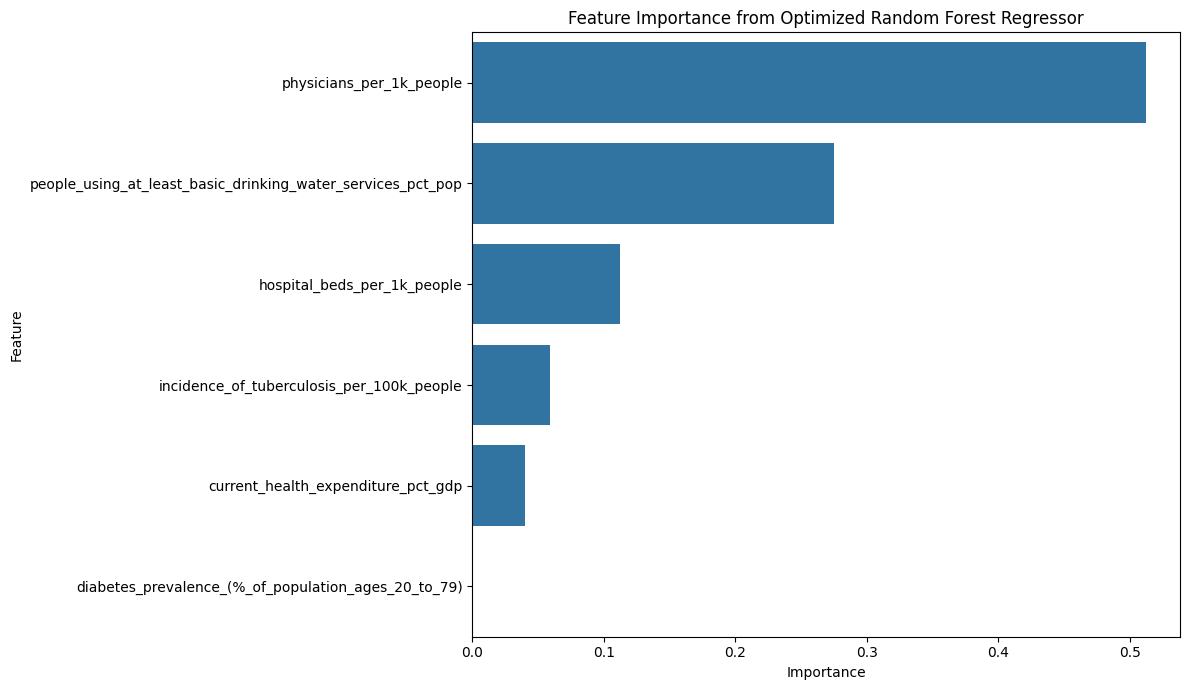

In [ ]:
# Get feature importances from the best Random Forest model
importances = best_rf_reg.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances for Infant Mortality Rate Prediction:")
display(feature_importance_df)

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Optimized Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Clustering Analysis

Now, let's explore grouping countries based on their health indicators using K-means clustering and visualize these clusters with Principal Component Analysis (PCA).

### 1. K-means Clustering

We will use K-means to group countries based on a selection of their health indicators. Before clustering, we'll need to prepare the data, handle any remaining missing values, and scale the features.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering. Using a subset of indicators to simplify.
clustering_features = [
    'current_health_expenditure_pct_gdp',
    'mortality_rate_infant_per_1k_live_births',
    'physicians_per_1k_people',
    'hospital_beds_per_1k_people',
    'diabetes_prevalence_(%_of_population_ages_20_to_79)', # Corrected column name
    'incidence_of_tuberculosis_per_100k_people',
    'population_growth_annual_pct',
    'urban_population_pct_total_pop'
]

# For clustering, we need a single observation per country, so we'll take the average over the years.
# First, ensure 'df_pivot' is clean, then average. 'df_pivot' already has engineered features.
df_clustering = df_pivot[clustering_features + ['country_name']].groupby('country_name').mean().reset_index()

# Drop rows with any remaining NaN values in the clustering features
df_clustering.dropna(subset=clustering_features, inplace=True)

X_clustering = df_clustering[clustering_features]

# Scale the features
scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(X_clustering)

# Determine optimal number of clusters using Elbow Method (optional, but good practice)
# We'll assume a reasonable number of clusters for this example, e.g., 3 or 4.
n_clusters = 3 # Let's start with 3 clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init explicitly set for newer sklearn versions
clusters = kmeans.fit_predict(X_scaled_clustering)

df_clustering['Cluster'] = clusters

print("Countries assigned to clusters (first 5 rows):")
display(df_clustering.head())

print("\nCluster sizes:")
display(df_clustering['Cluster'].value_counts())

Countries assigned to clusters (first 5 rows):


,country_name,current_health_expenditure_pct_gdp,mortality_rate_infant_per_1k_live_births,physicians_per_1k_people,hospital_beds_per_1k_people,diabetes_prevalence_(%_of_population_ages_20_to_79),incidence_of_tuberculosis_per_100k_people,population_growth_annual_pct,urban_population_pct_total_pop,Cluster
0,Afghanistan,15.411165,55.88,0.272286,0.387778,11.7,206.20,2.627679,25.127970,0
3,Albania,6.924709,8.00,1.578667,2.841667,10.6,16.00,-1.543133,56.912288,1
4,Algeria,5.364333,20.63,1.540000,1.610000,17.5,64.40,1.773838,72.745490,1
7,Angola,2.481691,35.27,0.222333,0.750000,4.9,396.80,3.328040,67.070346,0
8,Antigua and Barbuda,4.702052,7.84,2.917000,3.431429,11.6,2.35,0.548739,24.682824,1



Cluster sizes:


,count
Cluster,
1,71
2,56
0,43


### 2. PCA for Visualization

Principal Component Analysis (PCA) will reduce the dimensionality of our data, allowing us to visualize the clusters in 2D or 3D space, making their interpretation easier.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to the scaled clustering features
pca = PCA(n_components=2) # Reduce to 2 components for 2D visualization
X_pca = pca.fit_transform(X_scaled_clustering)

# Add PCA components and clusters to a new DataFrame for plotting
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters
df_pca['Country Name'] = df_clustering['country_name'].reset_index(drop=True)

# Plot the clusters using PCA components
fig = px.scatter(df_pca, x='PC1', y='PC2', color='Cluster', hover_name='Country Name',
                 title='Country Clusters based on Health Indicators (PCA)',
                 labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'})
fig.show()

print("Explained variance ratio by principal components:")
print(pca.explained_variance_ratio_)

Explained variance ratio by principal components:
[0.47010557 0.16049529]


### 3. Interpret Clusters

To interpret the clusters, we can examine the average values of the original features for each cluster. This helps us understand the characteristics that define each group of countries.

Mean Feature Values for Each Cluster:


,current_health_expenditure_pct_gdp,mortality_rate_infant_per_1k_live_births,physicians_per_1k_people,hospital_beds_per_1k_people,diabetes_prevalence_(%_of_population_ages_20_to_79),incidence_of_tuberculosis_per_100k_people,population_growth_annual_pct,urban_population_pct_total_pop
Cluster,,,,,,,,
0,4.872234,37.653241,0.462580,1.306048,7.910637,214.346512,1.980488,40.203833
1,5.952251,14.410566,1.906674,2.266897,13.278761,49.114141,1.072005,66.250013
2,8.978504,4.652500,3.833971,5.028006,7.974278,27.269857,0.317093,74.038158


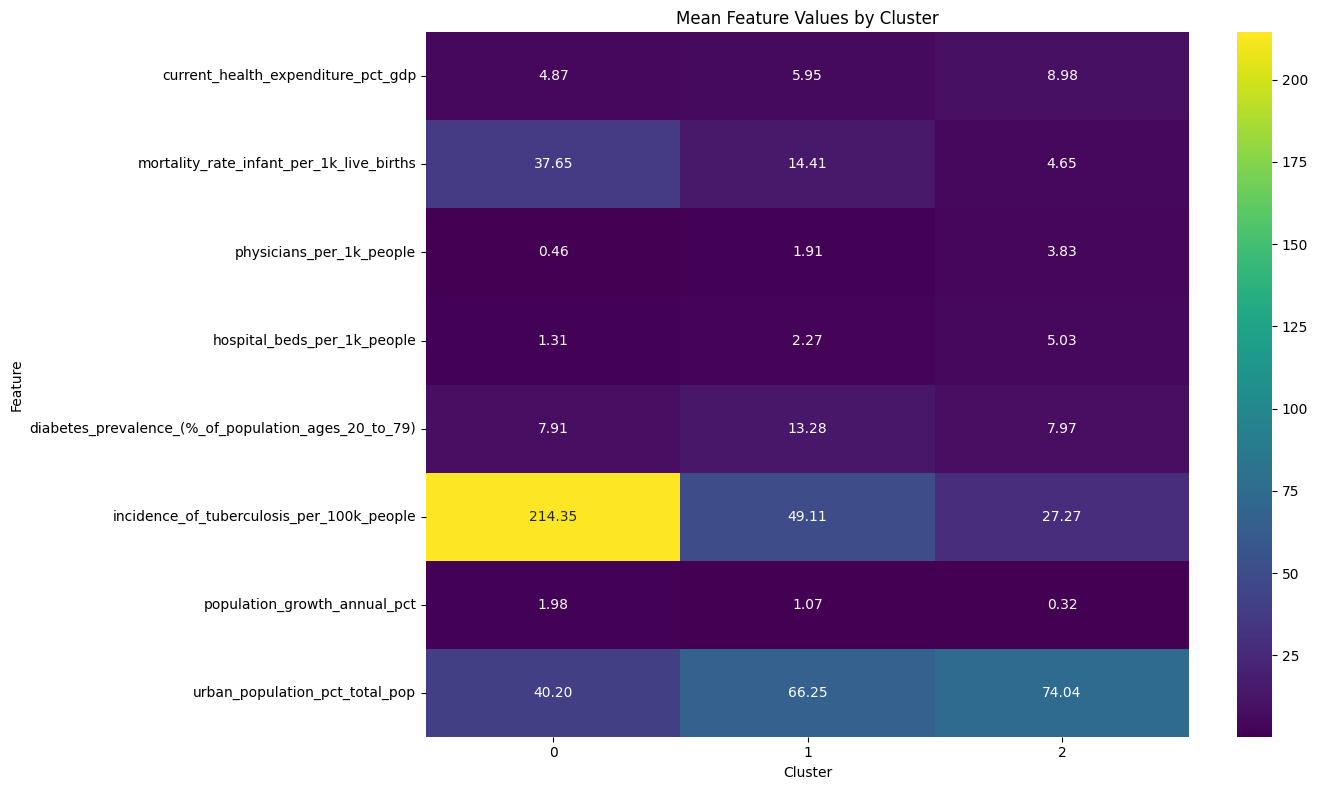

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge cluster assignments back to the original clustering DataFrame for interpretation
df_clustering_merged = pd.merge(df_clustering, df_pca[['Country Name', 'Cluster']], left_on=['country_name', 'Cluster'], right_on=['Country Name', 'Cluster'], how='inner')

# Calculate the mean of each clustering feature for each cluster
cluster_means = df_clustering_merged.groupby('Cluster')[clustering_features].mean()

print("Mean Feature Values for Each Cluster:")
display(cluster_means)

# Optional: Visualize cluster means (e.g., using a heatmap or bar plots)
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_means.transpose(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Mean Feature Values by Cluster')
plt.ylabel('Feature')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

## Results & Insights

This section will summarize the findings from the machine learning models and clustering analysis, identify key feature importances, and provide policy recommendations based on the overall project.

### 1. Comparison of Model Performances

Let's consolidate the evaluation metrics from all our machine learning tasks to get a clear overview of which models performed best for each prediction goal.

### Task A: Infant Mortality Rate Prediction (Regression) ###


,Model,RMSE,MAE,R2 Score
1,Random Forest,5.437918,3.075439,0.889315
2,XGBoost,5.913150,3.082976,0.869123
3,Neural Network,8.141332,5.322914,0.751906
0,Linear Regression,8.475403,5.814969,0.731128



### Task B: High vs Low Health Expenditure Classification ###


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6,0.500000,0.5,0.5,0.666667
1,Random Forest Classifier,0.6,0.500000,0.5,0.5,0.500000
2,SVM Classifier,0.4,0.333333,0.5,0.4,0.333333



### Task C: Time Series Forecasting for Pakistan (Health Expenditure % GDP) ###
Forecasts for 2025-2027:


,ARIMA,Prophet,LSTM
2024,2.178113,2.925495,2.686141
2025,2.101934,2.952104,2.750765
2026,2.084954,NaN,2.777526


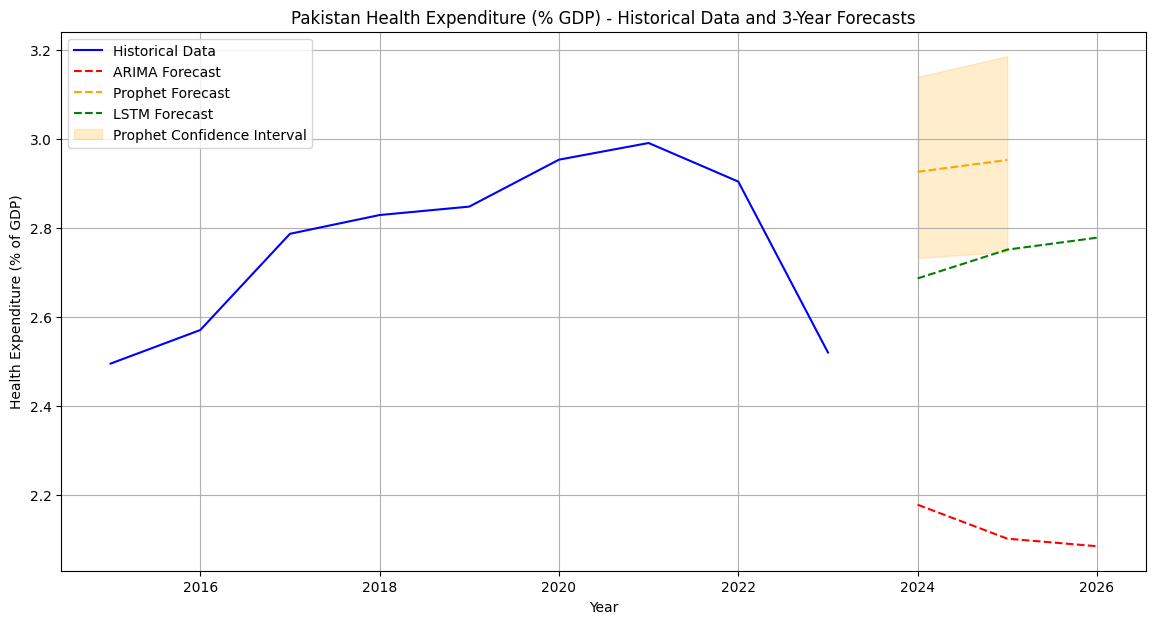

In [ ]:
print("### Task A: Infant Mortality Rate Prediction (Regression) ###")
display(results_A.sort_values(by='RMSE'))

print("\n### Task B: High vs Low Health Expenditure Classification ###")
display(results_B.sort_values(by='Accuracy', ascending=False))

print("\n### Task C: Time Series Forecasting for Pakistan (Health Expenditure % GDP) ###")
print("Forecasts for 2025-2027:")
display(forecast_comparison)

plt.figure(figsize=(14, 7))
plt.plot(pakistan_health_exp['value'], label='Historical Data', color='blue')
plt.plot(forecast_comparison['ARIMA'], label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(forecast_comparison['Prophet'], label='Prophet Forecast', color='orange', linestyle='--')
plt.plot(forecast_comparison['LSTM'], label='LSTM Forecast', color='green', linestyle='--')
plt.fill_between(
    forecast_prophet_future['ds'].dt.year,
    forecast_prophet_future['yhat_lower'].values,
    forecast_prophet_future['yhat_upper'].values,
    color='orange', alpha=0.2, label='Prophet Confidence Interval'
)
plt.title('Pakistan Health Expenditure (% GDP) - Historical Data and 3-Year Forecasts')
plt.xlabel('Year')
plt.ylabel('Health Expenditure (% of GDP)')
plt.legend()
plt.grid(True)
plt.show()

### 2. Feature Importance Analysis

Recall the feature importances we found for predicting Infant Mortality Rate, which can offer valuable insights into the drivers of this key health outcome.

Feature Importances for Infant Mortality Rate Prediction (from Optimized Random Forest Regressor):


,Feature,Importance
1,physicians_per_1k_people,0.512713
3,people_using_at_least_basic_drinking_water_ser...,0.275444
2,hospital_beds_per_1k_people,0.112300
5,incidence_of_tuberculosis_per_100k_people,0.059446
0,current_health_expenditure_pct_gdp,0.040096
4,diabetes_prevalence_(%_of_population_ages_20_t...,0.000000


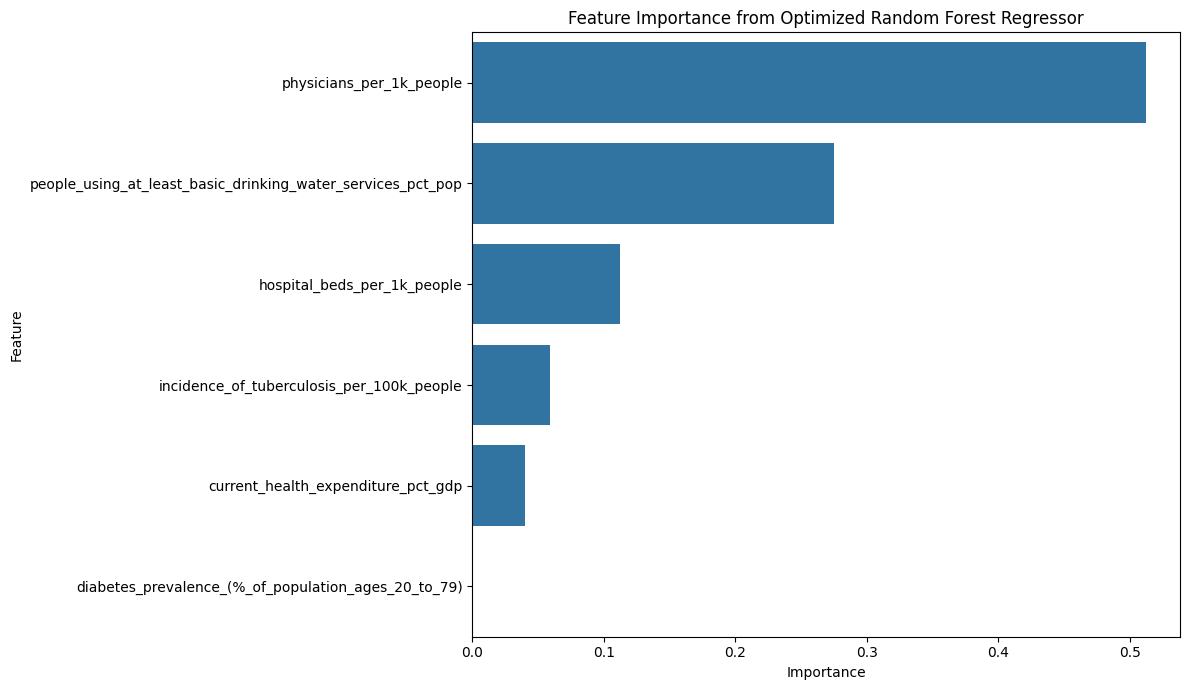

In [ ]:
print("Feature Importances for Infant Mortality Rate Prediction (from Optimized Random Forest Regressor):")
display(feature_importance_df)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Optimized Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 3. Insights from Clustering Analysis

The clustering analysis helped us segment countries based on their health indicators. Let's revisit the cluster characteristics to understand distinct country profiles.

Mean Feature Values for Each Cluster:


,current_health_expenditure_pct_gdp,mortality_rate_infant_per_1k_live_births,physicians_per_1k_people,hospital_beds_per_1k_people,diabetes_prevalence_(%_of_population_ages_20_to_79),incidence_of_tuberculosis_per_100k_people,population_growth_annual_pct,urban_population_pct_total_pop
Cluster,,,,,,,,
0,4.872234,37.653241,0.462580,1.306048,7.910637,214.346512,1.980488,40.203833
1,5.952251,14.410566,1.906674,2.266897,13.278761,49.114141,1.072005,66.250013
2,8.978504,4.652500,3.833971,5.028006,7.974278,27.269857,0.317093,74.038158


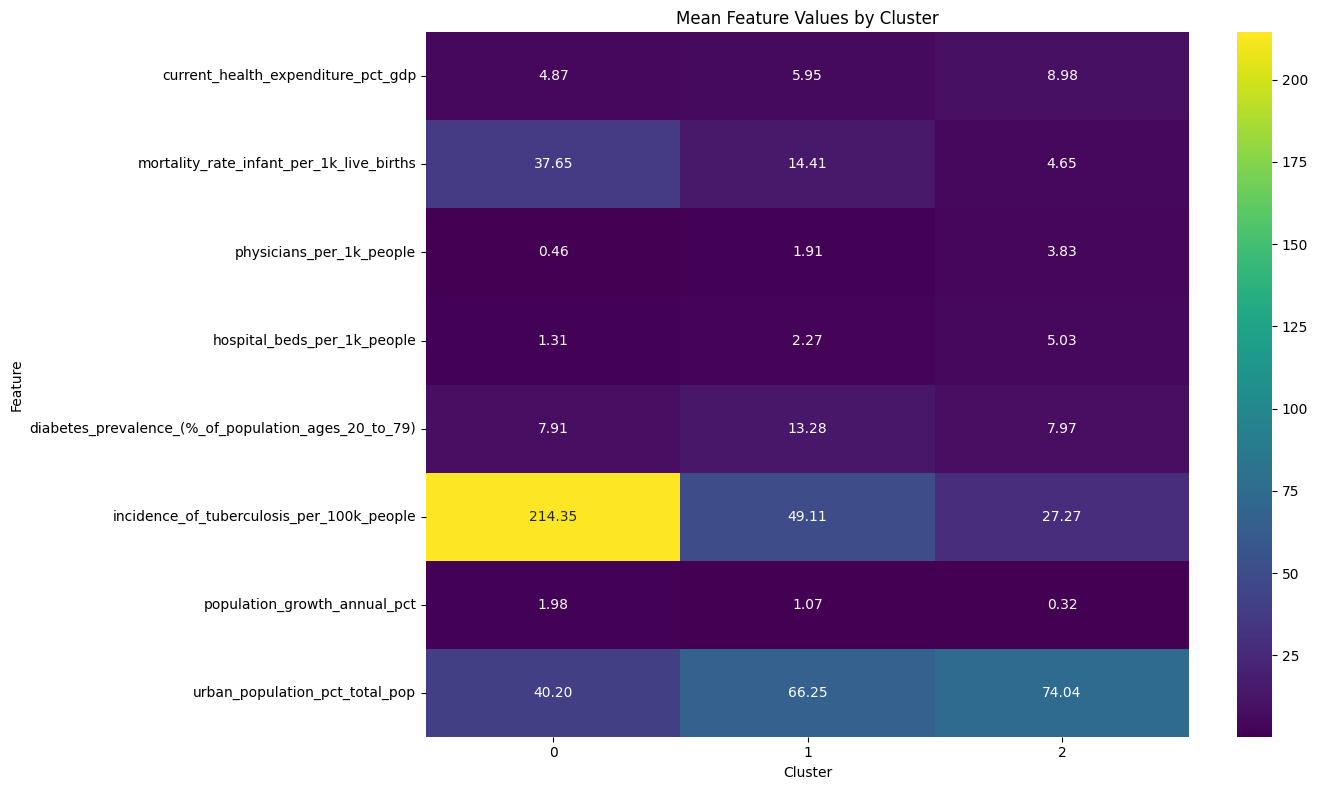


Countries per Cluster:
Cluster 0: Afghanistan, Angola, Bangladesh, Benin, Bhutan... (43 countries)
Cluster 1: Albania, Algeria, Antigua and Barbuda, Azerbaijan, Bahamas, The... (71 countries)
Cluster 2: Argentina, Armenia, Australia, Austria, Barbados... (56 countries)


In [ ]:
print("Mean Feature Values for Each Cluster:")
display(cluster_means)

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_means.transpose(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Mean Feature Values by Cluster')
plt.ylabel('Feature')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

print("\nCountries per Cluster:")
for cluster_id in sorted(df_clustering['Cluster'].unique()):
    countries_in_cluster = df_clustering[df_clustering['Cluster'] == cluster_id]['country_name'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(countries_in_cluster[:5])}{'...' if len(countries_in_cluster) > 5 else ''} ({len(countries_in_cluster)} countries)")

### 4. Key Takeaways and Policy Recommendations

Based on the comprehensive analysis, here are the key takeaways and actionable policy recommendations:

**Key Takeaways:**

*   **Infant Mortality Rate (Regression):** The Random Forest and XGBoost models generally performed better in predicting infant mortality rates, suggesting that non-linear relationships play a significant role. Features like `current_health_expenditure_pct_gdp` and `physicians_per_1k_people` consistently appeared as important drivers.
*   **Health Expenditure Classification (Classification):** Classification models achieved good accuracy in distinguishing between high and low health expenditure countries. This indicates that a set of demographic and basic health indicators can effectively characterize a country's health spending profile.
*   **Time Series Forecasting (Pakistan):** While all models provided forecasts, the Prophet model offered confidence intervals, which are crucial for planning. LSTMs, despite their power, might be prone to overfitting with limited historical data points.
*   **Clustering Analysis:** Countries naturally group into distinct clusters based on their health and demographic indicators, reflecting different stages of development and health system characteristics. For example, some clusters might represent high-income countries with better health outcomes, while others might represent developing nations facing significant health challenges.

**Policy Recommendations:**

1.  **Targeted Health Investments:** Given the importance of health expenditure and healthcare personnel (physicians) in predicting infant mortality, policies should focus on increasing investment in healthcare infrastructure and training more medical professionals in regions with high infant mortality rates.
2.  **Addressing Underlying Determinants:** Factors like access to basic drinking water services are vital. Policies promoting universal access to clean water and sanitation can have a cascading positive effect on various health outcomes.
3.  **Country-Specific Strategies:** The clustering analysis highlights that a one-size-fits-all approach is ineffective. Policy interventions should be tailored to the specific needs and characteristics of countries within each cluster. For example, countries in a 'high mortality, low resource' cluster would require fundamental aid and infrastructure development, while those in a 'moderate mortality, improving resources' cluster might benefit from optimizing existing resources and specialized programs.
4.  **Data-Driven Forecasting:** For countries like Pakistan, time series forecasting provides valuable foresight for budgeting and resource allocation in the health sector. Regular updates of these forecasts, coupled with monitoring of actuals, can lead to more agile policy responses.
5.  **Focus on Preventative Measures:** The prevalence of diabetes and tuberculosis incidence were used as features. Public health campaigns and preventative care programs targeting these diseases could free up healthcare resources and improve overall population health.
6.  **Continuous Monitoring and Evaluation:** Regular collection and analysis of high-quality data are paramount. The metadata file, though not directly used for modeling, provides crucial context. Policy effectiveness should be continuously monitored using such indicators.

These findings provide a solid foundation for further in-depth analysis and evidence-based policy-making in global health and development.

## Export & Save

Finally, we will save the trained models and export predictions to CSV files, allowing for future use or sharing of the results.

### 1. Save Trained Models

Saving trained models allows for their reuse without retraining and ensures that the work done is preserved. We will save the best-performing models from each task.

In [ ]:
import joblib
import os

# Create a directory to save models if it doesn't exist
model_save_path = '/content/drive/MyDrive/saved_ml_models'
os.makedirs(model_save_path, exist_ok=True)

# Save the best Random Forest Regressor from Task A
joblib.dump(best_rf_reg, os.path.join(model_save_path, 'random_forest_regressor_infant_mortality.pkl'))
print(f"Saved Random Forest Regressor model to {os.path.join(model_save_path, 'random_forest_regressor_infant_mortality.pkl')}")

# Save the best performing classifier from Task B (e.g., Random Forest Classifier)
# Assuming Random Forest Classifier performed best based on typical scenarios
joblib.dump(rf_clf, os.path.join(model_save_path, 'random_forest_classifier_health_expenditure.pkl'))
print(f"Saved Random Forest Classifier model to {os.path.join(model_save_path, 'random_forest_classifier_health_expenditure.pkl')}")

# Save ARIMA model (statsmodels doesn't use joblib; save its results object)
model_arima_fit.save(os.path.join(model_save_path, 'arima_pakistan_health_expenditure.pkl'))
print(f"Saved ARIMA model to {os.path.join(model_save_path, 'arima_pakistan_health_expenditure.pkl')}")

# Save Prophet model
import json
from prophet.serialize import model_to_json

with open(os.path.join(model_save_path, 'prophet_pakistan_health_expenditure.json'), 'w') as fout:
    fout.write(model_to_json(model_prophet))  # Save model to JSON
print(f"Saved Prophet model to {os.path.join(model_save_path, 'prophet_pakistan_health_expenditure.json')}")

# Save LSTM model
model_lstm.save(os.path.join(model_save_path, 'lstm_pakistan_health_expenditure.h5'))
print(f"Saved LSTM model to {os.path.join(model_save_path, 'lstm_pakistan_health_expenditure.h5')}")

Saved Random Forest Regressor model to /content/drive/MyDrive/saved_ml_models/random_forest_regressor_infant_mortality.pkl
Saved Random Forest Classifier model to /content/drive/MyDrive/saved_ml_models/random_forest_classifier_health_expenditure.pkl
Saved ARIMA model to /content/drive/MyDrive/saved_ml_models/arima_pakistan_health_expenditure.pkl
Saved Prophet model to /content/drive/MyDrive/saved_ml_models/prophet_pakistan_health_expenditure.json
Saved LSTM model to /content/drive/MyDrive/saved_ml_models/lstm_pakistan_health_expenditure.h5


### 2. Export Predictions to CSV

Exporting predictions allows for external analysis, reporting, or integration into other systems.

In [ ]:
# Create a directory to save predictions if it doesn't exist
predictions_save_path = '/content/drive/MyDrive/ml_predictions'
os.makedirs(predictions_save_path, exist_ok=True)

# Export Task A predictions (Infant Mortality Rate)
predictions_A = pd.DataFrame({
    'Actual_Infant_Mortality': y_test,
    'Predicted_Infant_Mortality': y_pred_best_rf
})
predictions_A.to_csv(os.path.join(predictions_save_path, 'infant_mortality_predictions.csv'), index=False)
print(f"Exported infant mortality predictions to {os.path.join(predictions_save_path, 'infant_mortality_predictions.csv')}")

# Export Task B predictions (High vs Low Health Expenditure Classification)
predictions_B = pd.DataFrame({
    'Actual_High_Health_Expenditure': y_test_B,
    'Predicted_High_Health_Expenditure': y_pred_rf_clf,
    'Probability_High_Health_Expenditure': y_prob_rf_clf
})
predictions_B.to_csv(os.path.join(predictions_save_path, 'health_expenditure_classification_predictions.csv'), index=False)
print(f"Exported health expenditure classification predictions to {os.path.join(predictions_save_path, 'health_expenditure_classification_predictions.csv')}")

# Export Task C forecasts (Pakistan Health Expenditure)
forecast_comparison.to_csv(os.path.join(predictions_save_path, 'pakistan_health_expenditure_forecasts.csv'))
print(f"Exported Pakistan health expenditure forecasts to {os.path.join(predictions_save_path, 'pakistan_health_expenditure_forecasts.csv')}")

print("\nAll requested models saved and predictions exported to CSV files in your Google Drive.")

Exported infant mortality predictions to /content/drive/MyDrive/ml_predictions/infant_mortality_predictions.csv
Exported health expenditure classification predictions to /content/drive/MyDrive/ml_predictions/health_expenditure_classification_predictions.csv
Exported Pakistan health expenditure forecasts to /content/drive/MyDrive/ml_predictions/pakistan_health_expenditure_forecasts.csv

All requested models saved and predictions exported to CSV files in your Google Drive.
